# 🚗 Vehicle Loan ML — Complete Pipeline
### Phase 1 to Phase 11 — Zero Leakage | Zero Overfitting

## 🔴 PHASE 1 — Data Understanding

In [ ]:
# Cell 1 — Libraries Import + CSV Load
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('Data/vehicle_loan_with_missing_values.csv')
print('CSV Load Ho Gaya ✅')

CSV Load Ho Gaya ✅


In [136]:
# Cell 2 — Step 1.1 → Shape
print('Rows    :', df.shape[0])
print('Columns :', df.shape[1])

Rows    : 300
Columns : 22


In [137]:
# Cell 3 — Step 1.3 → Data Types
print(df.dtypes)

name                        object
age                        float64
city_tier                   object
employment_type             object
monthly_income             float64
bank_avg_balance_6m        float64
existing_emi               float64
dti                        float64
cibil_score                float64
past_defaults              float64
inquiries_6m               float64
job_tenure_months          float64
vehicle_type                object
vehicle_price              float64
down_payment               float64
loan_amount_requested      float64
tenure_requested_months    float64
insurer_present            float64
co_applicant               float64
loan_status                  int64
approved_amount            float64
interest_rate              float64
dtype: object


In [138]:
# Cell 4 — Step 1.2 → Pehli 5 Rows
df.head()

,name,age,city_tier,employment_type,monthly_income,bank_avg_balance_6m,existing_emi,dti,cibil_score,past_defaults,...,vehicle_type,vehicle_price,down_payment,loan_amount_requested,tenure_requested_months,insurer_present,co_applicant,loan_status,approved_amount,interest_rate
0,Deepak Mishra_0,46.0,Metro,Govt,86069.0,133148.0,14277.0,0.296,683.0,0.0,...,Two-Wheeler,1221364.0,73095.0,145438.0,24.0,1.0,0.0,1,1117374.0,11.58
1,Priya Singh_1,32.0,Metro,Salaried,NaN,25559.0,3812.0,0.216,628.0,0.0,...,Four-Wheeler,330466.0,127886.0,NaN,12.0,1.0,0.0,1,902458.0,12.18
2,Rahul Sharma_2,NaN,Rural,Self-Employed,13801.0,98396.0,17844.0,0.447,607.0,2.0,...,Four-Wheeler,500930.0,295711.0,814448.0,24.0,1.0,0.0,1,201604.0,12.83
3,Sunita Chauhan_3,38.0,Rural,Salaried,27190.0,NaN,18117.0,0.411,575.0,0.0,...,Four-Wheeler,1448616.0,45292.0,284528.0,60.0,0.0,1.0,1,110130.0,14.37
4,Rohit Kumar_4,36.0,Metro,Govt,57689.0,26732.0,1605.0,0.177,775.0,2.0,...,Two-Wheeler,1160868.0,84813.0,NaN,NaN,0.0,NaN,0,808596.0,15.07


In [139]:
# Cell 5 — Step 1.4 → Describe
df.describe()

,age,monthly_income,bank_avg_balance_6m,existing_emi,dti,cibil_score,past_defaults,inquiries_6m,job_tenure_months,vehicle_price,down_payment,loan_amount_requested,tenure_requested_months,insurer_present,co_applicant,loan_status,approved_amount,interest_rate
count,285.000000,276.000000,270.000000,273.000000,264.000000,276.000000,285.000000,279.000000,270.000000,2.820000e+02,267.000000,2.790000e+02,285.000000,276.000000,282.000000,300.000000,2.730000e+02,255.000000
mean,37.091228,55403.264493,99276.451852,9795.915751,0.261652,700.228261,0.964912,2.670251,60.055556,7.974754e+05,159609.666667,6.067088e+05,36.294737,0.525362,0.446809,0.510000,6.885925e+05,12.931765
std,11.032224,27841.615620,54481.006489,5778.607243,0.149015,89.051377,0.808514,1.689646,34.757373,4.242053e+05,82572.669162,3.354978e+05,17.395892,0.500263,0.498046,0.500735,4.081756e+05,1.448124
min,18.000000,8412.000000,5404.000000,9.000000,0.013000,550.000000,0.000000,0.000000,1.000000,6.865800e+04,10138.000000,2.015900e+04,12.000000,0.000000,0.000000,0.000000,9.170000e+02,10.530000
25%,28.000000,30961.750000,54535.750000,4944.000000,0.126250,628.000000,0.000000,1.000000,29.250000,4.614815e+05,87004.500000,3.120195e+05,24.000000,0.000000,0.000000,0.000000,3.288210e+05,11.695000
50%,39.000000,56931.000000,102123.000000,9524.000000,0.275000,702.500000,1.000000,3.000000,58.000000,7.833600e+05,167584.000000,6.156000e+05,36.000000,1.000000,0.000000,1.000000,7.091320e+05,12.770000
75%,46.000000,80159.750000,142870.500000,14277.000000,0.401000,774.250000,2.000000,4.000000,90.000000,1.195809e+06,224572.500000,8.753560e+05,48.000000,1.000000,1.000000,1.000000,1.022582e+06,14.245000
max,54.000000,99794.000000,199053.000000,19956.000000,0.499000,849.000000,2.000000,5.000000,119.000000,1.499796e+06,298565.000000,1.196503e+06,60.000000,1.000000,1.000000,1.000000,1.399769e+06,15.490000


In [140]:
# Cell 6 — Step 1.4 → Null Values
null_df = pd.DataFrame({
    'Missing Count' : df.isnull().sum(),
    'Missing %'     : (df.isnull().sum() / len(df) * 100).round(2)
})
null_df[null_df['Missing Count'] > 0].sort_values('Missing Count', ascending=False)

,Missing Count,Missing %
interest_rate,45,15.0
dti,36,12.0
down_payment,33,11.0
bank_avg_balance_6m,30,10.0
job_tenure_months,30,10.0
approved_amount,27,9.0
existing_emi,27,9.0
monthly_income,24,8.0
cibil_score,24,8.0
insurer_present,24,8.0


In [141]:
# Cell 7 — Step 1.4 → Duplicate Rows
print('Duplicate Rows :', df.duplicated().sum())

Duplicate Rows : 0


In [142]:
# Cell 8 — Step 1.6 → Categorical Unique Values
for col in ['city_tier', 'employment_type', 'vehicle_type']:
    print(f'{col} → {df[col].unique()}')

city_tier → ['Metro' 'Rural' 'Urban' nan]
employment_type → ['Govt' 'Salaried' 'Self-Employed' nan]
vehicle_type → ['Two-Wheeler' 'Four-Wheeler']


In [143]:
# Cell 9 — Step 1.3 → Numerical vs Categorical
num_cols_info = df.select_dtypes(include=['float64', 'int64']).columns.tolist()
cat_cols_info = df.select_dtypes(include=['object']).columns.tolist()

print('Numerical Columns :', num_cols_info)
print('\nCategorical Columns :', cat_cols_info)

Numerical Columns : ['age', 'monthly_income', 'bank_avg_balance_6m', 'existing_emi', 'dti', 'cibil_score', 'past_defaults', 'inquiries_6m', 'job_tenure_months', 'vehicle_price', 'down_payment', 'loan_amount_requested', 'tenure_requested_months', 'insurer_present', 'co_applicant', 'loan_status', 'approved_amount', 'interest_rate']

Categorical Columns : ['name', 'city_tier', 'employment_type', 'vehicle_type']


In [144]:
# Cell 10 — Step 1.5 → Target Variables Check
print('loan_status value counts:')
print(df['loan_status'].value_counts())
print('\napproved_amount non-null rows :', df['approved_amount'].notnull().sum())
print('interest_rate  non-null rows :', df['interest_rate'].notnull().sum())

loan_status value counts:
loan_status
1    153
0    147
Name: count, dtype: int64

approved_amount non-null rows : 273
interest_rate  non-null rows : 255


## 🔴 PHASE 2 — Safe Cleaning (Split se Pehle)

In [145]:
# Cell 11 — Step 2.1 → name Column Drop
df.drop('name', axis=1, inplace=True)
print('name column drop ho gaya ✅')
print('Columns ab :', df.shape[1])

name column drop ho gaya ✅
Columns ab : 21


In [146]:
# Cell 12 — Step 2.2 → Duplicate Rows Remove
before = df.shape[0]
df.drop_duplicates(inplace=True)
after = df.shape[0]
print(f'Pehle : {before} rows')
print(f'Baad  : {after} rows')
print(f'Remove hue : {before - after} duplicates')

Pehle : 300 rows
Baad  : 300 rows
Remove hue : 0 duplicates


In [147]:
# Cell 13 — Verify
print('Shape after cleaning :', df.shape)
print('Duplicate Rows       :', df.duplicated().sum())
print('name column hai kya  :', 'name' in df.columns)

Shape after cleaning : (300, 21)
Duplicate Rows       : 0
name column hai kya  : False


## 🔴 PHASE 3 — EDA (Exploratory Data Analysis)

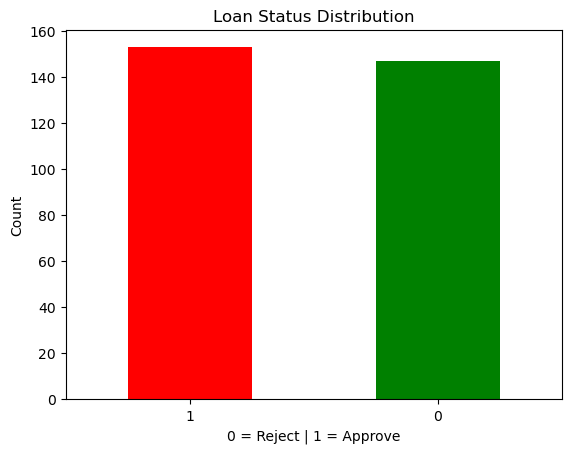

loan_status
1    153
0    147
Name: count, dtype: int64

Approved % : 51.0


In [148]:
# Cell 14 — Step 3.1 → Target Variable Distribution
df['loan_status'].value_counts().plot(kind='bar', color=['red','green'])
plt.title('Loan Status Distribution')
plt.xlabel('0 = Reject | 1 = Approve')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.show()
print(df['loan_status'].value_counts())
print('\nApproved % :', round(df['loan_status'].mean()*100, 2))

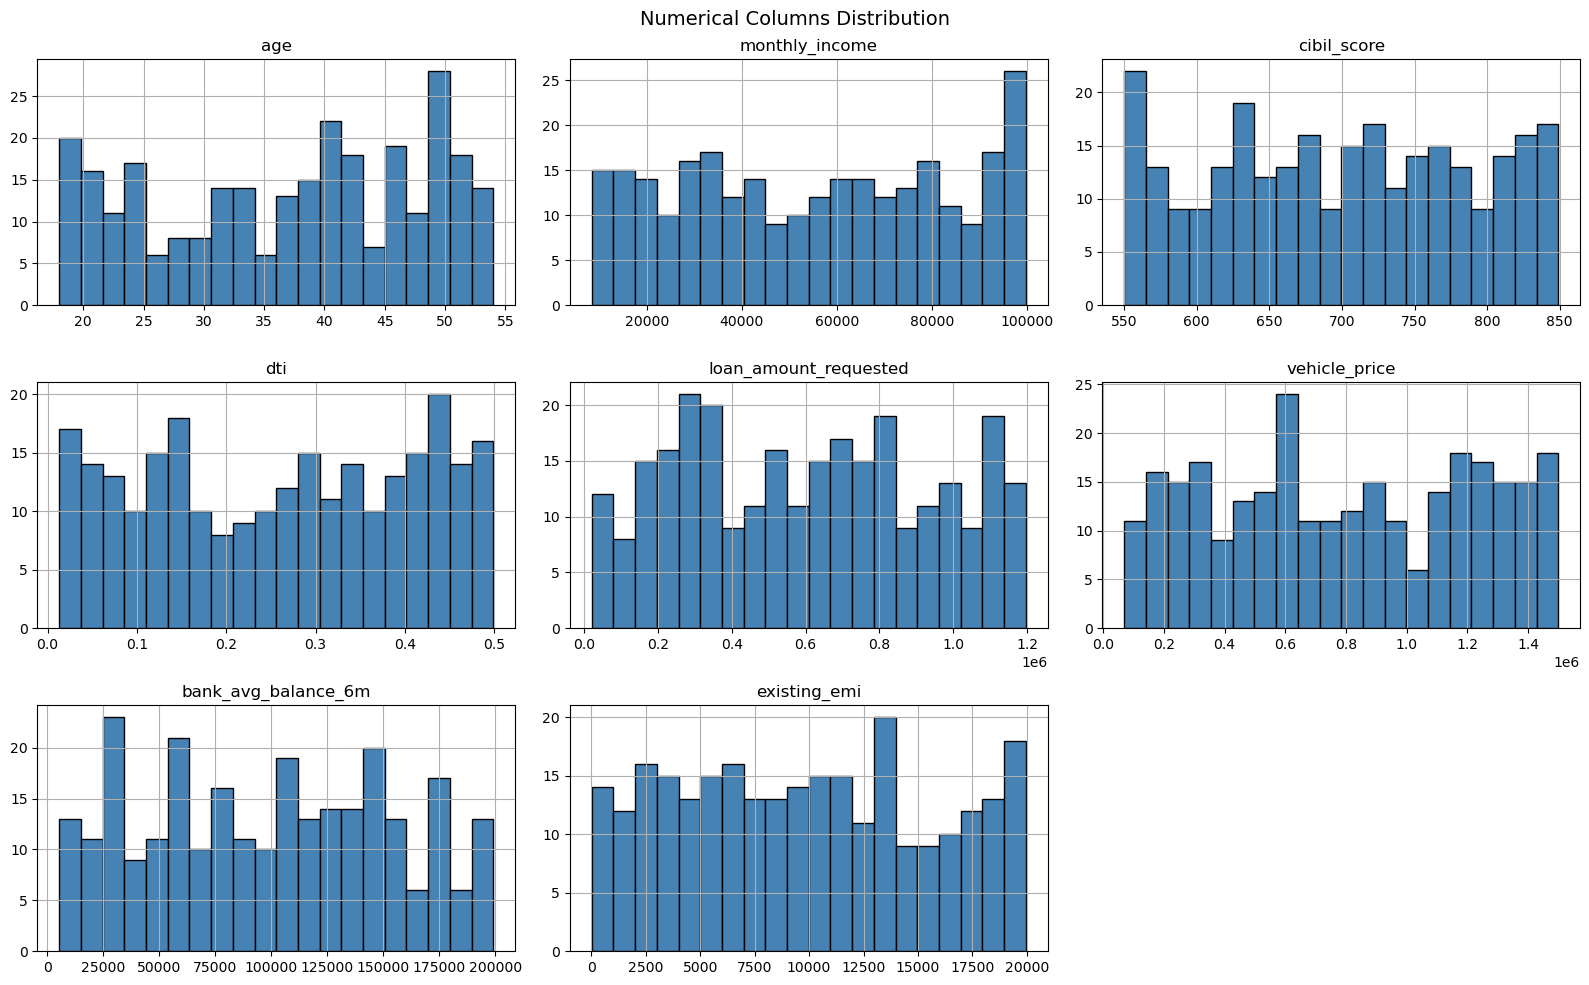

In [149]:
# Cell 15 — Step 3.2 → Numerical Distributions
num_plot_cols = ['age', 'monthly_income', 'cibil_score', 'dti',
                 'loan_amount_requested', 'vehicle_price',
                 'bank_avg_balance_6m', 'existing_emi']

df[num_plot_cols].hist(figsize=(16, 10), bins=20,
                       color='steelblue', edgecolor='black')
plt.suptitle('Numerical Columns Distribution', fontsize=14)
plt.tight_layout()
plt.show()

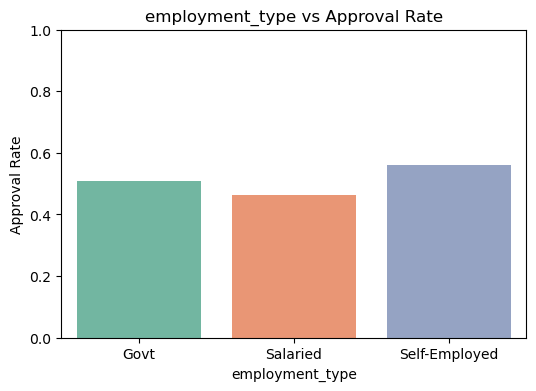

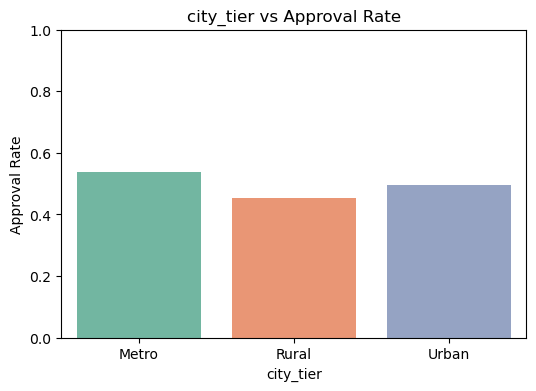

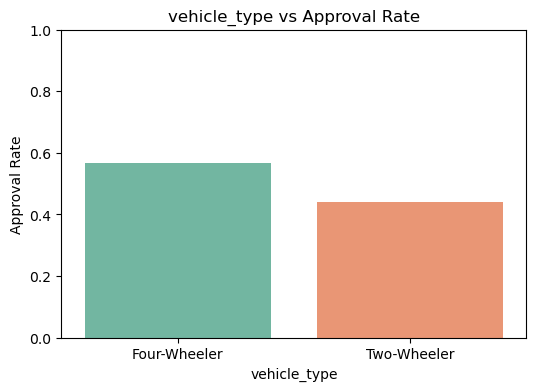

In [150]:
# Cell 16 — Step 3.3 → Categorical vs loan_status
for col in ['employment_type', 'city_tier', 'vehicle_type']:
    ct = df.groupby(col)['loan_status'].mean().reset_index()
    ct.columns = [col, 'approval_rate']
    plt.figure(figsize=(6, 4))
    sns.barplot(x=col, y='approval_rate', data=ct,
                hue=col, palette='Set2', legend=False)
    plt.title(f'{col} vs Approval Rate')
    plt.ylabel('Approval Rate')
    plt.ylim(0, 1)
    plt.show()

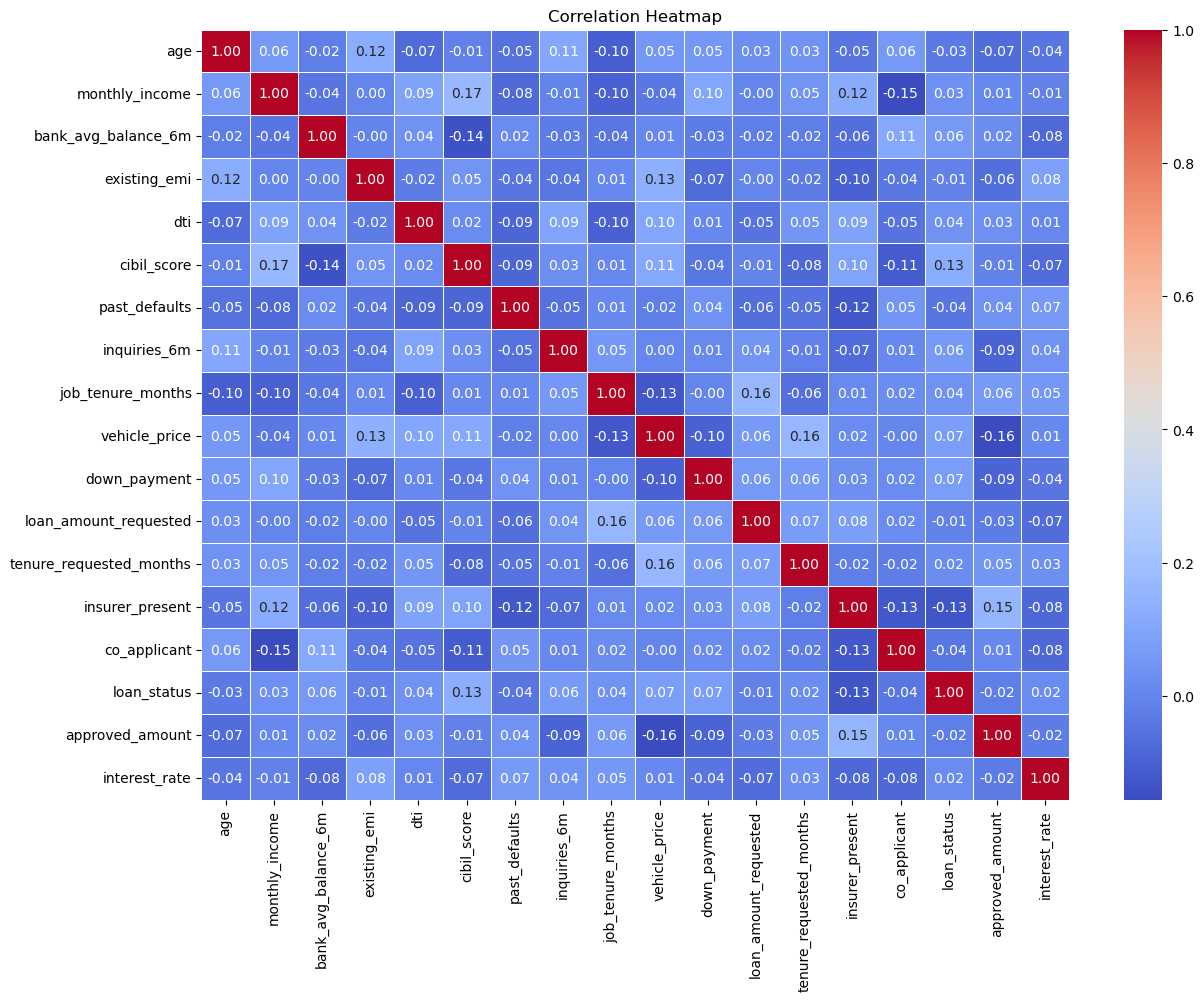

In [151]:
# Cell 17 — Step 3.4 → Correlation Heatmap
plt.figure(figsize=(14, 10))
sns.heatmap(
    df.select_dtypes(include='number').corr(),
    annot=True, fmt='.2f', cmap='coolwarm', linewidths=0.5
)
plt.title('Correlation Heatmap')
plt.show()

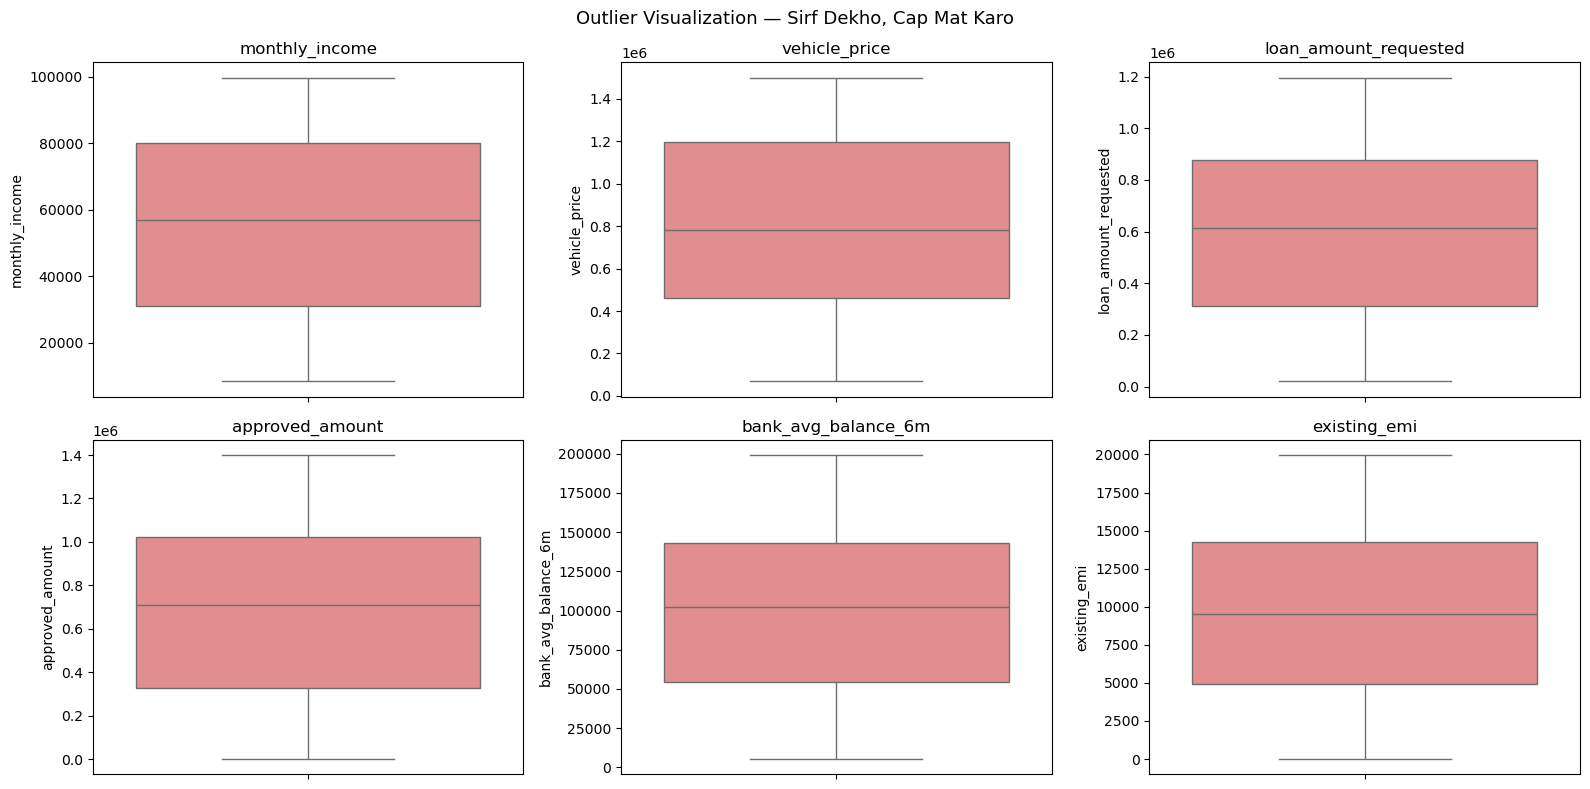

In [152]:
# Cell 18 — Step 3.5 → Outlier Visualization (Sirf Dekho)
outlier_plot_cols = ['monthly_income', 'vehicle_price',
                     'loan_amount_requested', 'approved_amount',
                     'bank_avg_balance_6m', 'existing_emi']

fig, axes = plt.subplots(2, 3, figsize=(16, 8))
axes = axes.flatten()
for i, col in enumerate(outlier_plot_cols):
    sns.boxplot(y=df[col], ax=axes[i], color='lightcoral')
    axes[i].set_title(col)
plt.suptitle('Outlier Visualization — Sirf Dekho, Cap Mat Karo', fontsize=13)
plt.tight_layout()
plt.show()

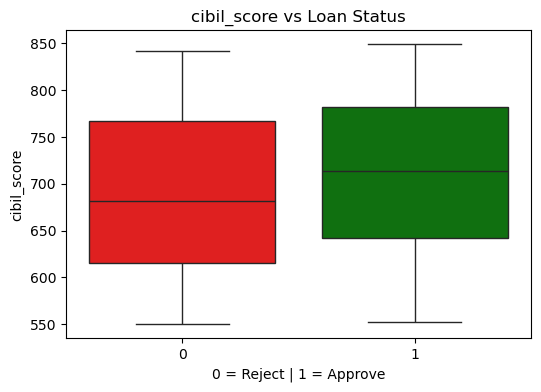

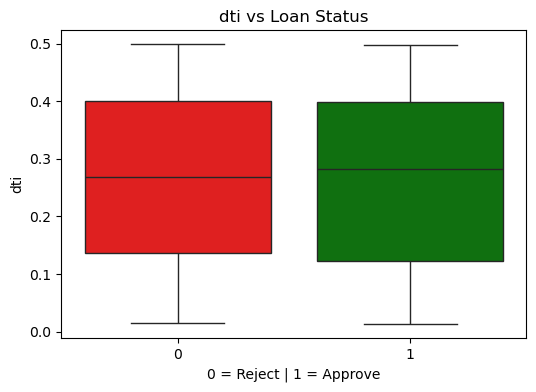

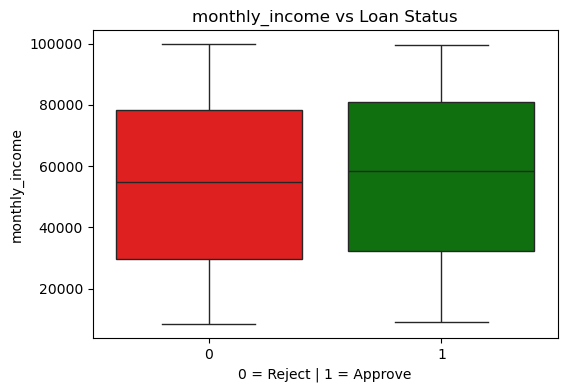

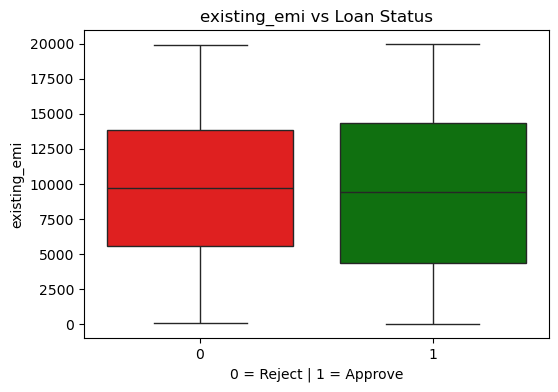

In [153]:
# Cell 19 — Step 3.6 → Key Features vs loan_status Boxplot
for col in ['cibil_score', 'dti', 'monthly_income', 'existing_emi']:
    plt.figure(figsize=(6, 4))
    sns.boxplot(x='loan_status', y=col, data=df,
                hue='loan_status', palette={0:'red', 1:'green'}, legend=False)
    plt.title(f'{col} vs Loan Status')
    plt.xlabel('0 = Reject | 1 = Approve')
    plt.show()

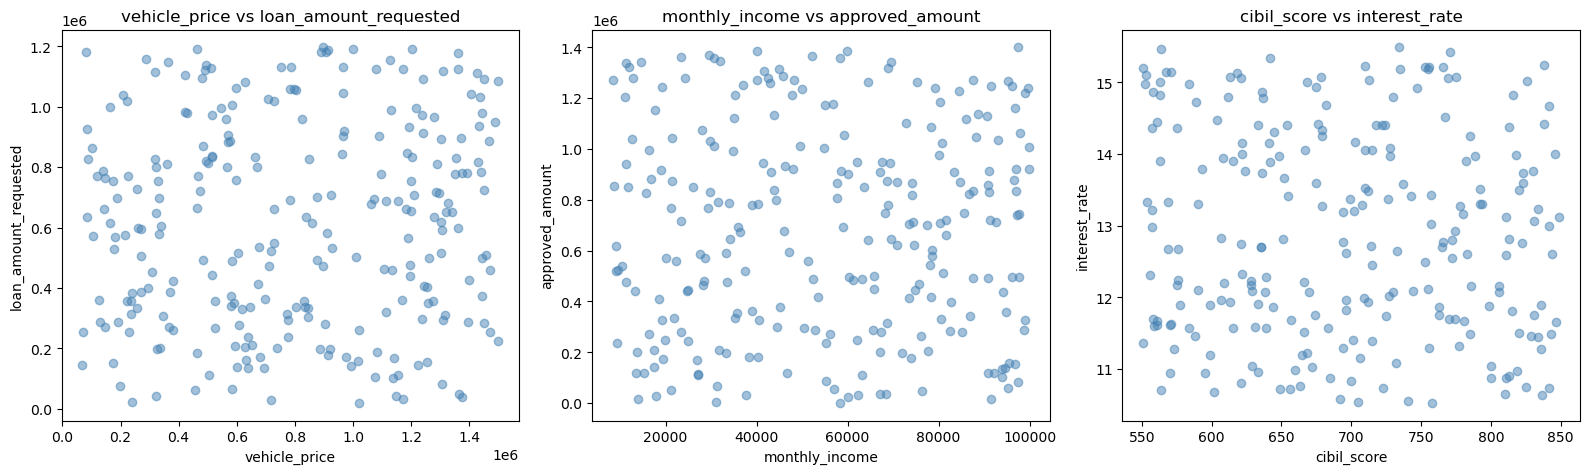

In [154]:
# Cell 20 — Step 3.6 → Scatter Plots
scatter_pairs = [
    ('vehicle_price',  'loan_amount_requested'),
    ('monthly_income', 'approved_amount'),
    ('cibil_score',    'interest_rate')
]
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
for i, (x, y) in enumerate(scatter_pairs):
    temp = df[[x, y]].dropna()
    axes[i].scatter(temp[x], temp[y], alpha=0.5, color='steelblue')
    axes[i].set_xlabel(x)
    axes[i].set_ylabel(y)
    axes[i].set_title(f'{x} vs {y}')
plt.tight_layout()
plt.show()

In [155]:
# Cell 21 — Step 3.7 → Key Observations
print('='*55)
print('KEY OBSERVATIONS')
print('='*55)
print('\n1. CIBIL Score — Approved vs Rejected:')
print(df.groupby('loan_status')['cibil_score'].mean().round(2))
print('\n2. DTI — Approved vs Rejected:')
print(df.groupby('loan_status')['dti'].mean().round(3))
print('\n3. Monthly Income — Approved vs Rejected:')
print(df.groupby('loan_status')['monthly_income'].mean().round(2))
print('\n4. Employment Type — Approval Rate:')
print(df.groupby('employment_type')['loan_status'].mean().round(3))
print('\n5. City Tier — Approval Rate:')
print(df.groupby('city_tier')['loan_status'].mean().round(3))
print('\n6. Interest Rate Range:')
print(f'   Min : {df["interest_rate"].min()}')
print(f'   Max : {df["interest_rate"].max()}')
print(f'   Gap : {round(df["interest_rate"].max() - df["interest_rate"].min(), 2)}%')
print('   ⚠️  Gap sirf 5% — Regression R² low aayega, normal hai')

KEY OBSERVATIONS

1. CIBIL Score — Approved vs Rejected:
loan_status
0    688.61
1    711.51
Name: cibil_score, dtype: float64

2. DTI — Approved vs Rejected:
loan_status
0    0.256
1    0.267
Name: dti, dtype: float64

3. Monthly Income — Approved vs Rejected:
loan_status
0    54561.56
1    56209.16
Name: monthly_income, dtype: float64

4. Employment Type — Approval Rate:
employment_type
Govt             0.510
Salaried         0.463
Self-Employed    0.560
Name: loan_status, dtype: float64

5. City Tier — Approval Rate:
city_tier
Metro    0.538
Rural    0.455
Urban    0.494
Name: loan_status, dtype: float64

6. Interest Rate Range:
   Min : 10.53
   Max : 15.49
   Gap : 4.96%
   ⚠️  Gap sirf 5% — Regression R² low aayega, normal hai


## 🔴 PHASE 4 — Feature Engineering (Split se Pehle)

In [156]:
# Cell 22 — Step 4.1 → Nayi Features Create Karo
# +1 isliye — zero division se bachne ke liye
df['loan_utilization']   = df['loan_amount_requested'] / (df['vehicle_price'] + 1)
df['emi_burden']         = df['existing_emi'] / (df['monthly_income'] + 1)
df['net_income']         = df['monthly_income'] - df['existing_emi']
df['down_payment_ratio'] = df['down_payment'] / (df['vehicle_price'] + 1)
df['balance_to_income']  = df['bank_avg_balance_6m'] / (df['monthly_income'] + 1)

# ✅ NaN safe high_risk
df['high_risk'] = (
    (df['past_defaults'].fillna(0) > 0) &
    (df['cibil_score'].fillna(999) < 650)
).astype(int)

print('Nayi Features Create Ho Gayi ✅')
print('Columns ab :', df.shape[1])
print('\nhigh_risk value counts:')
print(df['high_risk'].value_counts())

Nayi Features Create Ho Gayi ✅
Columns ab : 27

high_risk value counts:
high_risk
0    231
1     69
Name: count, dtype: int64


In [157]:
# Cell 23 — Inf Values Fix Karo
print('Inf values before fix:')
print(np.isinf(df.select_dtypes(include='number')).sum()[lambda x: x > 0])

df.replace([np.inf, -np.inf], np.nan, inplace=True)

print('\n✅ Inf values fix ho gayi')

Inf values before fix:
Series([], dtype: int64)

✅ Inf values fix ho gayi


Nayi Features ka loan_status se Correlation:
net_income            0.054
emi_burden            0.024
balance_to_income    -0.008
down_payment_ratio   -0.041
loan_utilization     -0.097
high_risk            -0.130
Name: loan_status, dtype: float64


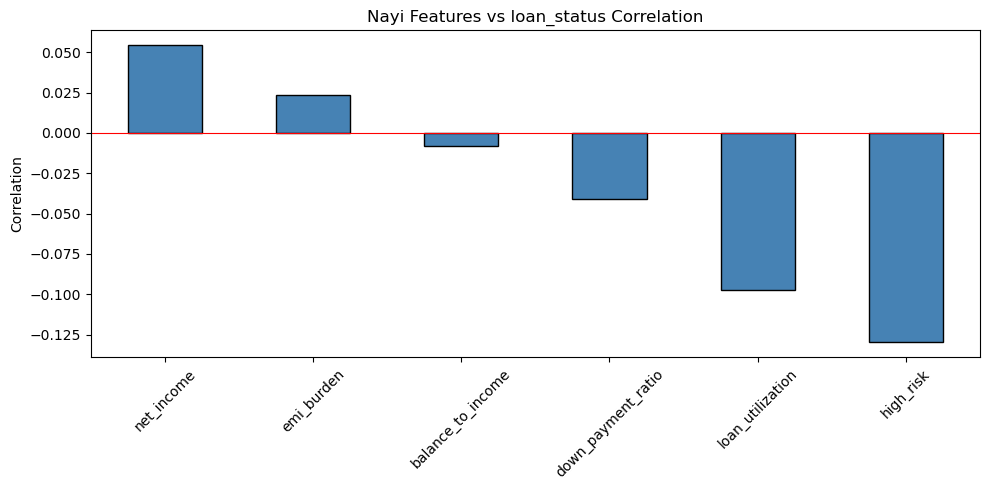

In [158]:
# Cell 24 — Step 4.2 → Nayi Features ki Target se Correlation
new_features = ['loan_utilization', 'emi_burden', 'net_income',
                'down_payment_ratio', 'balance_to_income', 'high_risk']

corr_with_target = df[new_features + ['loan_status']].corr()['loan_status'].drop('loan_status')
corr_with_target = corr_with_target.sort_values(ascending=False)
print('Nayi Features ka loan_status se Correlation:')
print(corr_with_target.round(3))

corr_with_target.plot(kind='bar', color='steelblue', edgecolor='black', figsize=(10, 5))
plt.title('Nayi Features vs loan_status Correlation')
plt.ylabel('Correlation')
plt.axhline(0, color='red', linewidth=0.8)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [159]:
# Cell 25 — Step 4.3 → Highly Correlated Pairs Check
corr_matrix = df.select_dtypes(include='number').corr().abs()
upper = corr_matrix.where(
    np.triu(np.ones(corr_matrix.shape), k=1).astype(bool)
)
high_corr_pairs = [(col, row)
                   for col in upper.columns
                   for row in upper.index
                   if upper.loc[row, col] > 0.90]

print('Highly Correlated Pairs (>0.90):')
if high_corr_pairs:
    for pair in high_corr_pairs:
        print(f'  {pair[0]}  ↔  {pair[1]}')
    print('\n⚠️ net_income ↔ monthly_income highly correlated')
    print('net_income ko Phase 11 mein drop karenge')
else:
    print('  Koi highly correlated pair nahi ✅')

Highly Correlated Pairs (>0.90):
  net_income  ↔  monthly_income

⚠️ net_income ↔ monthly_income highly correlated
net_income ko Phase 11 mein drop karenge


## 🔴 PHASE 5 — Datasets Prepare Karo

In [160]:
# Cell 26 — Dataset A — Classification
X_A = df.drop(['loan_status', 'approved_amount', 'interest_rate'], axis=1)
y_A = df['loan_status']
print('Dataset A — Classification')
print('X_A shape :', X_A.shape)
print('y_A distribution:', y_A.value_counts().to_dict())

Dataset A — Classification
X_A shape : (300, 24)
y_A distribution: {1: 153, 0: 147}


In [161]:
# Cell 27 — Dataset B — Regression 1 (Approved Amount)
df_B = df[df['loan_status'] == 1].copy()
X_B  = df_B.drop(['loan_status', 'approved_amount', 'interest_rate'], axis=1)
y_B  = df_B['approved_amount']
print('Dataset B — Regression 1 (Approved Amount)')
print('Sirf approved rows liye ✅')
print('X_B shape :', X_B.shape)

Dataset B — Regression 1 (Approved Amount)
Sirf approved rows liye ✅
X_B shape : (153, 24)


In [162]:
# Cell 28 — Dataset C — Regression 2 (Interest Rate)
df_C = df[df['interest_rate'].notnull()].copy()
X_C  = df_C.drop(['loan_status', 'approved_amount', 'interest_rate'], axis=1)
y_C  = df_C['interest_rate']
print('Dataset C — Regression 2 (Interest Rate)')
print('Sirf non-null interest_rate rows liye ✅')
print('X_C shape :', X_C.shape)

Dataset C — Regression 2 (Interest Rate)
Sirf non-null interest_rate rows liye ✅
X_C shape : (255, 24)


In [163]:
# Cell 29 — Dataset D — Clustering
cluster_cols = ['age', 'monthly_income', 'cibil_score', 'dti',
                'vehicle_price', 'loan_amount_requested',
                'emi_burden', 'net_income', 'balance_to_income']
X_D = df[cluster_cols].copy()
print('Dataset D — Clustering')
print('Koi target nahi — unsupervised ✅')
print('X_D shape :', X_D.shape)

Dataset D — Clustering
Koi target nahi — unsupervised ✅
X_D shape : (300, 9)


In [164]:
# Cell 30 — Leakage Check
leaky_cols = ['loan_status', 'approved_amount', 'interest_rate']
for ds_name, ds in [('A', X_A), ('B', X_B), ('C', X_C)]:
    print(f'Dataset {ds_name} — Leaky Columns Check:')
    for col in leaky_cols:
        status = '❌ LEAKAGE!' if col in ds.columns else '✅ Safe'
        print(f'  {col} in X_{ds_name} → {status}')
    print()

Dataset A — Leaky Columns Check:
  loan_status in X_A → ✅ Safe
  approved_amount in X_A → ✅ Safe
  interest_rate in X_A → ✅ Safe

Dataset B — Leaky Columns Check:
  loan_status in X_B → ✅ Safe
  approved_amount in X_B → ✅ Safe
  interest_rate in X_B → ✅ Safe

Dataset C — Leaky Columns Check:
  loan_status in X_C → ✅ Safe
  approved_amount in X_C → ✅ Safe
  interest_rate in X_C → ✅ Safe



## 🔴 PHASE 6 — Train Test Split

In [165]:
# Cell 31 — Split
from sklearn.model_selection import train_test_split

# Dataset A — stratify lagao
X_train_A, X_test_A, y_train_A, y_test_A = train_test_split(
    X_A, y_A, test_size=0.2, random_state=42, stratify=y_A
)

# Dataset B
X_train_B, X_test_B, y_train_B, y_test_B = train_test_split(
    X_B, y_B, test_size=0.2, random_state=42
)

# Dataset C
X_train_C, X_test_C, y_train_C, y_test_C = train_test_split(
    X_C, y_C, test_size=0.2, random_state=42
)

print('='*50)
print('TRAIN TEST SPLIT SUMMARY')
print('='*50)
print(f'Dataset A Train → X: {X_train_A.shape} | y: {y_train_A.shape}')
print(f'Dataset A Test  → X: {X_test_A.shape}  | y: {y_test_A.shape}')
print(f'Train Approved % : {round(y_train_A.mean()*100,2)} | Test Approved % : {round(y_test_A.mean()*100,2)}')
print(f'\nDataset B Train → X: {X_train_B.shape} | y: {y_train_B.shape}')
print(f'Dataset B Test  → X: {X_test_B.shape}  | y: {y_test_B.shape}')
print(f'\nDataset C Train → X: {X_train_C.shape} | y: {y_train_C.shape}')
print(f'Dataset C Test  → X: {X_test_C.shape}  | y: {y_test_C.shape}')
print(f'\nDataset D       → Poora: {X_D.shape} | Split nahi ✅')

TRAIN TEST SPLIT SUMMARY
Dataset A Train → X: (240, 24) | y: (240,)
Dataset A Test  → X: (60, 24)  | y: (60,)
Train Approved % : 50.83 | Test Approved % : 51.67

Dataset B Train → X: (122, 24) | y: (122,)
Dataset B Test  → X: (31, 24)  | y: (31,)

Dataset C Train → X: (204, 24) | y: (204,)
Dataset C Test  → X: (51, 24)  | y: (51,)

Dataset D       → Poora: (300, 9) | Split nahi ✅


## 🔴 PHASE 7 — Missing Value Imputation (Split ke BAAD)

In [166]:
# Cell 32 — Columns Define + Imputers
from sklearn.impute import SimpleImputer

num_cols = ['age', 'monthly_income', 'bank_avg_balance_6m', 'existing_emi',
            'dti', 'cibil_score', 'past_defaults', 'inquiries_6m',
            'job_tenure_months', 'vehicle_price', 'down_payment',
            'loan_amount_requested', 'tenure_requested_months',
            'insurer_present', 'co_applicant',
            'loan_utilization', 'emi_burden', 'net_income',
            'down_payment_ratio', 'balance_to_income']

cat_cols = ['city_tier', 'employment_type']

# Dataset A
num_imp_A = SimpleImputer(strategy='median')
X_train_A[num_cols] = num_imp_A.fit_transform(X_train_A[num_cols])
X_test_A[num_cols]  = num_imp_A.transform(X_test_A[num_cols])

cat_imp_A = SimpleImputer(strategy='most_frequent')
X_train_A[cat_cols] = cat_imp_A.fit_transform(X_train_A[cat_cols])
X_test_A[cat_cols]  = cat_imp_A.transform(X_test_A[cat_cols])

# Dataset B
num_imp_B = SimpleImputer(strategy='median')
X_train_B[num_cols] = num_imp_B.fit_transform(X_train_B[num_cols])
X_test_B[num_cols]  = num_imp_B.transform(X_test_B[num_cols])

cat_imp_B = SimpleImputer(strategy='most_frequent')
X_train_B[cat_cols] = cat_imp_B.fit_transform(X_train_B[cat_cols])
X_test_B[cat_cols]  = cat_imp_B.transform(X_test_B[cat_cols])

# Dataset C
num_imp_C = SimpleImputer(strategy='median')
X_train_C[num_cols] = num_imp_C.fit_transform(X_train_C[num_cols])
X_test_C[num_cols]  = num_imp_C.transform(X_test_C[num_cols])

cat_imp_C = SimpleImputer(strategy='most_frequent')
X_train_C[cat_cols] = cat_imp_C.fit_transform(X_train_C[cat_cols])
X_test_C[cat_cols]  = cat_imp_C.transform(X_test_C[cat_cols])

print('Imputation Done — Teeno Datasets ✅')
print(f'X_train_A missing : {X_train_A.isnull().sum().sum()}')
print(f'X_train_B missing : {X_train_B.isnull().sum().sum()}')
print(f'X_train_C missing : {X_train_C.isnull().sum().sum()}')

Imputation Done — Teeno Datasets ✅
X_train_A missing : 0
X_train_B missing : 0
X_train_C missing : 0


## 🔴 PHASE 8 — Outlier Capping (Split ke BAAD)

In [167]:
# Cell 33 — Outlier Capping — Teeno Datasets

def get_iqr_bounds(df_train, cols):
    """Sirf train se bounds calculate karo"""
    bounds = {}
    for col in cols:
        Q1  = df_train[col].quantile(0.25)
        Q3  = df_train[col].quantile(0.75)
        IQR = Q3 - Q1
        bounds[col] = (Q1 - 1.5*IQR, Q3 + 1.5*IQR)
    return bounds

def apply_capping(df_train, df_test, bounds, cols):
    """Train ke bounds — dono pe apply karo"""
    for col in cols:
        lo, hi = bounds[col]
        df_train.loc[:, col] = df_train[col].clip(lo, hi)
        df_test.loc[:, col]  = df_test[col].clip(lo, hi)

# Dataset A
outlier_bounds_A = get_iqr_bounds(X_train_A, num_cols)
apply_capping(X_train_A, X_test_A, outlier_bounds_A, num_cols)
print('Dataset A — Outlier Capping Done ✅')

# Dataset B
outlier_bounds_B = get_iqr_bounds(X_train_B, num_cols)
apply_capping(X_train_B, X_test_B, outlier_bounds_B, num_cols)
print('Dataset B — Outlier Capping Done ✅')

# Dataset C
outlier_bounds_C = get_iqr_bounds(X_train_C, num_cols)
apply_capping(X_train_C, X_test_C, outlier_bounds_C, num_cols)
print('Dataset C — Outlier Capping Done ✅')

Dataset A — Outlier Capping Done ✅
Dataset B — Outlier Capping Done ✅
Dataset C — Outlier Capping Done ✅


In [168]:
# Cell 34 — Verify Capping
print('Dataset A — Out of bounds check:')
all_clear = True
for col in num_cols:
    lo, hi = outlier_bounds_A[col]
    train_out = ((X_train_A[col] < lo) | (X_train_A[col] > hi)).sum()
    test_out  = ((X_test_A[col] < lo)  | (X_test_A[col] > hi)).sum()
    if train_out > 0 or test_out > 0:
        print(f'  ⚠️ {col} → Train: {train_out} | Test: {test_out}')
        all_clear = False
if all_clear:
    print('  Sab values bounds ke andar hain ✅')

Dataset A — Out of bounds check:
  Sab values bounds ke andar hain ✅


## 🔴 PHASE 9 — Encoding (Split ke BAAD)

In [169]:
# Cell 35 — Encoding — Teeno Datasets
from sklearn.preprocessing import OrdinalEncoder, OneHotEncoder, LabelEncoder

def encode_dataset(X_train, X_test, suffix):
    """Encoding — sirf train pe fit"""
    # Ordinal — city_tier
    oe = OrdinalEncoder(categories=[['Rural', 'Urban', 'Metro']])
    X_train[['city_tier']] = oe.fit_transform(X_train[['city_tier']])
    X_test[['city_tier']]  = oe.transform(X_test[['city_tier']])

    # One-Hot — employment_type
    ohe = OneHotEncoder(drop='first', sparse_output=False)
    emp_train = ohe.fit_transform(X_train[['employment_type']])
    emp_test  = ohe.transform(X_test[['employment_type']])
    emp_cols  = ohe.get_feature_names_out(['employment_type'])
    X_train[emp_cols] = emp_train
    X_test[emp_cols]  = emp_test
    X_train.drop('employment_type', axis=1, inplace=True)
    X_test.drop('employment_type',  axis=1, inplace=True)

    # Label — vehicle_type
    le = LabelEncoder()
    X_train['vehicle_type'] = le.fit_transform(X_train['vehicle_type'])
    X_test['vehicle_type']  = le.transform(X_test['vehicle_type'])

    print(f'Dataset {suffix} — Encoding Done ✅ | Shape: {X_train.shape}')
    return oe, ohe, le

oe_A, ohe_A, le_A = encode_dataset(X_train_A, X_test_A, 'A')
oe_B, ohe_B, le_B = encode_dataset(X_train_B, X_test_B, 'B')
oe_C, ohe_C, le_C = encode_dataset(X_train_C, X_test_C, 'C')

Dataset A — Encoding Done ✅ | Shape: (240, 25)
Dataset B — Encoding Done ✅ | Shape: (122, 25)
Dataset C — Encoding Done ✅ | Shape: (204, 25)


In [170]:
# Cell 36 — Verify Encoding
for name, X_tr in [('A', X_train_A), ('B', X_train_B), ('C', X_train_C)]:
    cat_remaining = X_tr.select_dtypes(include='object').columns.tolist()
    status = '✅ None' if not cat_remaining else f'❌ {cat_remaining}'
    print(f'Dataset {name} — Categorical columns baaki: {status}')

Dataset A — Categorical columns baaki: ✅ None
Dataset B — Categorical columns baaki: ✅ None
Dataset C — Categorical columns baaki: ✅ None


## 🔴 PHASE 10 — Scaling (Split ke BAAD)

In [171]:
# Cell 37 — Scaling — Teeno Datasets
from sklearn.preprocessing import StandardScaler, MinMaxScaler

scale_cols = ['age', 'monthly_income', 'bank_avg_balance_6m', 'existing_emi',
              'dti', 'cibil_score', 'past_defaults', 'inquiries_6m',
              'job_tenure_months', 'vehicle_price', 'down_payment',
              'loan_amount_requested', 'tenure_requested_months',
              'insurer_present', 'co_applicant',
              'loan_utilization', 'emi_burden', 'net_income',
              'down_payment_ratio', 'balance_to_income']

# Dataset A
scaler_A = StandardScaler()
X_train_A[scale_cols] = scaler_A.fit_transform(X_train_A[scale_cols])
X_test_A[scale_cols]  = scaler_A.transform(X_test_A[scale_cols])
print('Dataset A — Scaling Done ✅')

# Dataset B
scaler_B = StandardScaler()
X_train_B[scale_cols] = scaler_B.fit_transform(X_train_B[scale_cols])
X_test_B[scale_cols]  = scaler_B.transform(X_test_B[scale_cols])
print('Dataset B — Scaling Done ✅')

# Dataset C
scaler_C = StandardScaler()
X_train_C[scale_cols] = scaler_C.fit_transform(X_train_C[scale_cols])
X_test_C[scale_cols]  = scaler_C.transform(X_test_C[scale_cols])
print('Dataset C — Scaling Done ✅')

Dataset A — Scaling Done ✅
Dataset B — Scaling Done ✅
Dataset C — Scaling Done ✅


In [172]:
# Cell 38 — Dataset D — MinMaxScaler (Clustering)
num_imp_D  = SimpleImputer(strategy='median')
X_D_imp    = num_imp_D.fit_transform(X_D)

mm_scaler  = MinMaxScaler()
X_D_scaled = mm_scaler.fit_transform(X_D_imp)

print('Dataset D — MinMaxScaler Done ✅')
print('X_D_scaled shape :', X_D_scaled.shape)

Dataset D — MinMaxScaler Done ✅
X_D_scaled shape : (300, 9)


In [173]:
# Cell 39 — Final Shape Verify
print('='*55)
print('FINAL SHAPES AFTER COMPLETE PREPROCESSING')
print('='*55)
print(f'X_train_A : {X_train_A.shape} | X_test_A : {X_test_A.shape}')
print(f'X_train_B : {X_train_B.shape} | X_test_B : {X_test_B.shape}')
print(f'X_train_C : {X_train_C.shape} | X_test_C : {X_test_C.shape}')
print(f'X_D_scaled: {X_D_scaled.shape} | Clustering poora data')
print('\n✅ Preprocessing Complete — Models ke liye ready!')

FINAL SHAPES AFTER COMPLETE PREPROCESSING
X_train_A : (240, 25) | X_test_A : (60, 25)
X_train_B : (122, 25) | X_test_B : (31, 25)
X_train_C : (204, 25) | X_test_C : (51, 25)
X_D_scaled: (300, 9) | Clustering poora data

✅ Preprocessing Complete — Models ke liye ready!


## 🔴 PHASE 11 — Classification

In [174]:
# Cell 40 — Libraries Import
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from xgboost import XGBClassifier
from sklearn.model_selection import cross_val_score, RandomizedSearchCV
from sklearn.metrics import (f1_score, roc_auc_score, precision_score,
                              recall_score, accuracy_score,
                              confusion_matrix, classification_report)
print('Libraries Import Done ✅')

Libraries Import Done ✅


In [175]:
# Cell 41 — Models Define (Strict Regularization)
models = {
    'Logistic Regression' : LogisticRegression(
                                C=0.01,
                                max_iter=1000,
                                random_state=42),

    'Decision Tree'       : DecisionTreeClassifier(
                                max_depth=3,
                                min_samples_leaf=10,
                                random_state=42),

    'Random Forest'       : RandomForestClassifier(
                                n_estimators=100,
                                max_depth=4,
                                min_samples_leaf=10,
                                max_features='sqrt',
                                random_state=42),

    'Gradient Boosting'   : GradientBoostingClassifier(
                                n_estimators=50,
                                max_depth=2,
                                learning_rate=0.05,
                                subsample=0.8,
                                random_state=42),

    'XGBoost'             : XGBClassifier(
                                n_estimators=50,
                                max_depth=3,
                                learning_rate=0.05,
                                subsample=0.8,
                                colsample_bytree=0.8,
                                reg_alpha=0.1,
                                reg_lambda=1.0,
                                random_state=42,
                                eval_metric='logloss'),

    'KNN'                 : KNeighborsClassifier(n_neighbors=7),

    'SVM'                 : SVC(C=0.1, kernel='rbf',
                                probability=True, random_state=42)
}
print('Models Ready ✅')

Models Ready ✅


In [176]:
# Cell 42 — ✅ CORRECT Feature Selection
# net_income drop karo — monthly_income se highly correlated (>0.90)
# balance_to_income drop karo — near-zero correlation (0.008)

drop_features = ['net_income', 'balance_to_income']

X_train_A = X_train_A.drop(columns=drop_features)
X_test_A  = X_test_A.drop(columns=drop_features)

print(f'Features pehle : 25')
print(f'Features baad  : {X_train_A.shape[1]}')
print(f'Dropped        : {drop_features}')
print('\nRemaining features:')
print(X_train_A.columns.tolist())

Features pehle : 25
Features baad  : 23
Dropped        : ['net_income', 'balance_to_income']

Remaining features:
['age', 'city_tier', 'monthly_income', 'bank_avg_balance_6m', 'existing_emi', 'dti', 'cibil_score', 'past_defaults', 'inquiries_6m', 'job_tenure_months', 'vehicle_type', 'vehicle_price', 'down_payment', 'loan_amount_requested', 'tenure_requested_months', 'insurer_present', 'co_applicant', 'loan_utilization', 'emi_burden', 'down_payment_ratio', 'high_risk', 'employment_type_Salaried', 'employment_type_Self-Employed']


In [177]:
# Cell 43 — CV + Test Score Compare Karo
results_cv = {}

for name, model in models.items():
    cv_scores = cross_val_score(
        model, X_train_A, y_train_A, cv=5, scoring='f1'
    )
    model.fit(X_train_A, y_train_A)
    y_pred   = model.predict(X_test_A)
    test_f1  = f1_score(y_test_A, y_pred)
    test_auc = roc_auc_score(y_test_A, model.predict_proba(X_test_A)[:,1])
    gap      = abs(cv_scores.mean() - test_f1)

    results_cv[name] = {
        'CV F1'  : round(cv_scores.mean(), 3),
        'CV Std' : round(cv_scores.std(), 3),
        'Test F1': round(test_f1, 3),
        'ROC-AUC': round(test_auc, 3),
        'Gap'    : round(gap, 3)
    }
    flag = '⚠️  Overfitting' if gap > 0.05 else '✅ Stable'
    print(f'{name:<25} CV F1: {cv_scores.mean():.3f} | Test F1: {test_f1:.3f} | {flag}')

Logistic Regression       CV F1: 0.527 | Test F1: 0.525 | ✅ Stable
Decision Tree             CV F1: 0.462 | Test F1: 0.318 | ⚠️  Overfitting
Random Forest             CV F1: 0.499 | Test F1: 0.525 | ✅ Stable
Gradient Boosting         CV F1: 0.552 | Test F1: 0.542 | ✅ Stable
XGBoost                   CV F1: 0.513 | Test F1: 0.456 | ⚠️  Overfitting
KNN                       CV F1: 0.548 | Test F1: 0.500 | ✅ Stable
SVM                       CV F1: 0.674 | Test F1: 0.681 | ✅ Stable


In [178]:
# Cell 44 — Hyperparameter Tuning (Best Model)
xgb_params = {
    'n_estimators'    : [50, 100, 150],
    'max_depth'       : [2, 3, 4],
    'learning_rate'   : [0.03, 0.05, 0.1],
    'subsample'       : [0.7, 0.8],
    'colsample_bytree': [0.7, 0.8],
    'reg_alpha'       : [0.0, 0.1, 0.5],
    'reg_lambda'      : [0.5, 1.0, 2.0]
}

rs_clf = RandomizedSearchCV(
    XGBClassifier(random_state=42, eval_metric='logloss'),
    xgb_params,
    n_iter=30,
    cv=5,
    scoring='f1',
    random_state=42,
    n_jobs=-1
)
rs_clf.fit(X_train_A, y_train_A)

print('Best Params :', rs_clf.best_params_)
print('Best CV F1  :', round(rs_clf.best_score_, 3))

Best Params : {'subsample': 0.7, 'reg_lambda': 1.0, 'reg_alpha': 0.5, 'n_estimators': 50, 'max_depth': 3, 'learning_rate': 0.03, 'colsample_bytree': 0.8}
Best CV F1  : 0.543


In [179]:
# Cell 45 — Final Comparison Table
results_final = []

for name, model in models.items():
    model.fit(X_train_A, y_train_A)
    y_train_pred = model.predict(X_train_A)
    y_test_pred  = model.predict(X_test_A)

    train_f1  = f1_score(y_train_A, y_train_pred)
    test_f1   = f1_score(y_test_A, y_test_pred)
    gap       = abs(train_f1 - test_f1)

    results_final.append({
        'Model'    : name,
        'Train F1' : round(train_f1, 4),
        'Test F1'  : round(test_f1, 4),
        'Precision': round(precision_score(y_test_A, y_test_pred), 4),
        'Recall'   : round(recall_score(y_test_A, y_test_pred), 4),
        'Accuracy' : round(accuracy_score(y_test_A, y_test_pred), 4),
        'ROC-AUC'  : round(roc_auc_score(y_test_A, model.predict_proba(X_test_A)[:,1]), 4),
        'Gap'      : round(gap, 4),
        'Overfit?' : '⚠️ Overfit' if gap > 0.05 else '✅ Good'
    })

# Tuned model add karo
y_tr_t = rs_clf.predict(X_train_A)
y_te_t = rs_clf.predict(X_test_A)
gap_t  = abs(f1_score(y_train_A, y_tr_t) - f1_score(y_test_A, y_te_t))
results_final.append({
    'Model'    : 'XGBoost (Tuned)',
    'Train F1' : round(f1_score(y_train_A, y_tr_t), 4),
    'Test F1'  : round(f1_score(y_test_A, y_te_t), 4),
    'Precision': round(precision_score(y_test_A, y_te_t), 4),
    'Recall'   : round(recall_score(y_test_A, y_te_t), 4),
    'Accuracy' : round(accuracy_score(y_test_A, y_te_t), 4),
    'ROC-AUC'  : round(roc_auc_score(y_test_A, rs_clf.predict_proba(X_test_A)[:,1]), 4),
    'Gap'      : round(gap_t, 4),
    'Overfit?' : '⚠️ Overfit' if gap_t > 0.05 else '✅ Good'
})

results_df = pd.DataFrame(results_final).sort_values('Test F1', ascending=False).reset_index(drop=True)

print('='*100)
print('  CLASSIFICATION — ALL MODELS COMPARISON')
print('='*100)
print(results_df.to_string(index=False))
print()
best_row = results_df.iloc[0]
print(f'🏆 Best Model : {best_row["Model"]}')
print(f'   Test F1    : {best_row["Test F1"]}')
print(f'   ROC-AUC    : {best_row["ROC-AUC"]}')
print(f'   Precision  : {best_row["Precision"]}')
print(f'   Recall     : {best_row["Recall"]}')

  CLASSIFICATION — ALL MODELS COMPARISON
              Model  Train F1  Test F1  Precision  Recall  Accuracy  ROC-AUC    Gap   Overfit?
                SVM    0.6740   0.6813     0.5167  1.0000    0.5167   0.5078 0.0073     ✅ Good
  Gradient Boosting    0.8455   0.5424     0.5714  0.5161    0.5500   0.5495 0.3032 ⚠️ Overfit
Logistic Regression    0.6357   0.5246     0.5333  0.5161    0.5167   0.5617 0.1111 ⚠️ Overfit
      Random Forest    0.8664   0.5246     0.5333  0.5161    0.5167   0.4472 0.3418 ⚠️ Overfit
    XGBoost (Tuned)    0.8740   0.5246     0.5333  0.5161    0.5167   0.5217 0.3494 ⚠️ Overfit
                KNN    0.6780   0.5000     0.5172  0.4839    0.5000   0.4922 0.1780 ⚠️ Overfit
            XGBoost    0.9200   0.4561     0.5000  0.4194    0.4833   0.5006 0.4639 ⚠️ Overfit
      Decision Tree    0.5550   0.3182     0.5385  0.2258    0.5000   0.5056 0.2368 ⚠️ Overfit

🏆 Best Model : SVM
   Test F1    : 0.6813
   ROC-AUC    : 0.5078
   Precision  : 0.5167
   Recall     :

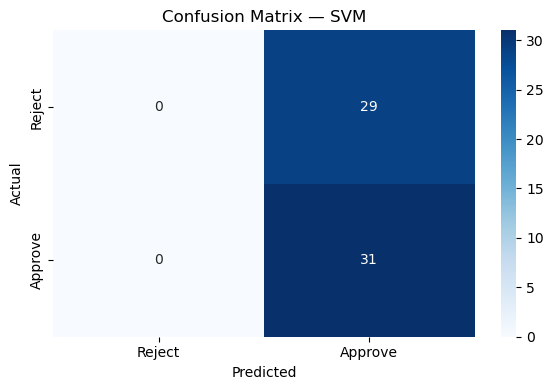

              precision    recall  f1-score   support

      Reject       0.00      0.00      0.00        29
     Approve       0.52      1.00      0.68        31

    accuracy                           0.52        60
   macro avg       0.26      0.50      0.34        60
weighted avg       0.27      0.52      0.35        60



c:\Users\Rahul Kumar Jha\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\Rahul Kumar Jha\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\Rahul Kumar Jha\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0]

In [180]:
# Cell 46 — Best Model Confusion Matrix
best_name  = results_df.iloc[0]['Model']
if best_name == 'XGBoost (Tuned)':
    best_model = rs_clf
else:
    best_model = models[best_name]

y_pred_best = best_model.predict(X_test_A)
cm = confusion_matrix(y_test_A, y_pred_best)

plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Reject', 'Approve'],
            yticklabels=['Reject', 'Approve'])
plt.title(f'Confusion Matrix — {best_name}')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.show()

print(classification_report(y_test_A, y_pred_best,
                             target_names=['Reject', 'Approve']))

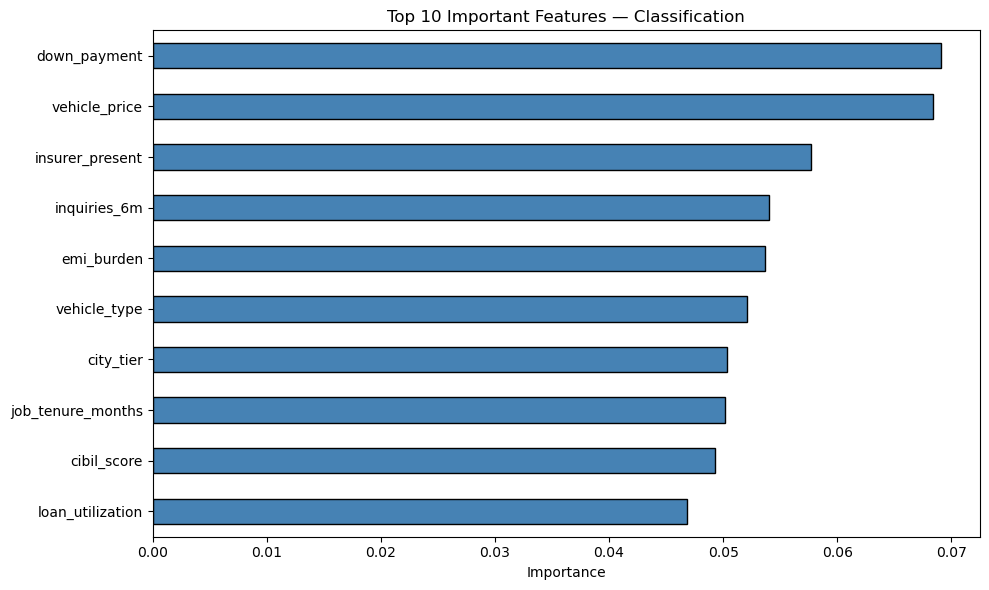


Top 5 Features:
down_payment       0.0691
vehicle_price      0.0684
insurer_present    0.0577
inquiries_6m       0.0540
emi_burden         0.0537
dtype: float32


In [181]:
# Cell 47 — Feature Importance
best_estimator = rs_clf.best_estimator_

feat_imp = pd.Series(
    best_estimator.feature_importances_,
    index=X_train_A.columns
).sort_values(ascending=False)

plt.figure(figsize=(10, 6))
feat_imp[:10].plot(kind='barh', color='steelblue', edgecolor='black')
plt.title('Top 10 Important Features — Classification')
plt.xlabel('Importance')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

print('\nTop 5 Features:')
print(feat_imp.head(5).round(4))

In [182]:
# Cell 48 — Models Save Karo
import joblib

joblib.dump(rs_clf.best_estimator_, 'best_clf_model.pkl')
joblib.dump(scaler_A,  'scaler_A.pkl')
joblib.dump(num_imp_A, 'num_imputer_A.pkl')
joblib.dump(cat_imp_A, 'cat_imputer_A.pkl')
joblib.dump(oe_A,      'ordinal_encoder_A.pkl')
joblib.dump(ohe_A,     'onehot_encoder_A.pkl')
joblib.dump(le_A,      'label_encoder_A.pkl')

print('✅ Best Classification Model Saved!')
print('✅ Scaler, Imputer, Encoder — Sab Save!')
print('\n⚠️ Production mein predict karne ke liye')
print('   model ke saath scaler+imputer+encoder bhi load karna hoga')

✅ Best Classification Model Saved!
✅ Scaler, Imputer, Encoder — Sab Save!

⚠️ Production mein predict karne ke liye
   model ke saath scaler+imputer+encoder bhi load karna hoga


**REGRESSION**

In [193]:
from sklearn.linear_model import Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import KFold, cross_val_score
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

print("Libraries Import Done ✅")

Libraries Import Done ✅


In [194]:
print("Dataset B — Preprocessing Check")
print("=" * 45)
print(f"X_train_B shape  : {X_train_B.shape}")
print(f"X_test_B  shape  : {X_test_B.shape}")
print(f"y_train_B NaN    : {y_train_B.isnull().sum()}")
print(f"y_test_B  NaN    : {y_test_B.isnull().sum()}")
print(f"Missing Train    : {X_train_B.isnull().sum().sum()}")
print(f"Missing Test     : {X_test_B.isnull().sum().sum()}")

Dataset B — Preprocessing Check
X_train_B shape  : (109, 25)
X_test_B  shape  : (28, 25)
y_train_B NaN    : 0
y_test_B  NaN    : 0
Missing Train    : 0
Missing Test     : 0


In [195]:
print("BEFORE FIX:")
print(f"y_train_B NaN : {y_train_B.isnull().sum()}")
print(f"y_test_B  NaN : {y_test_B.isnull().sum()}")
print(f"X_train_B     : {X_train_B.shape}")
print(f"X_test_B      : {X_test_B.shape}")

# NaN index dhundho
nan_idx_train = y_train_B[y_train_B.isnull()].index.tolist()
nan_idx_test  = y_test_B[y_test_B.isnull()].index.tolist()

# X aur y dono se NaN rows drop karo
X_train_B = X_train_B.drop(index=nan_idx_train)
y_train_B = y_train_B.drop(index=nan_idx_train)
X_test_B  = X_test_B.drop(index=nan_idx_test)
y_test_B  = y_test_B.drop(index=nan_idx_test)

# Reset index
X_train_B = X_train_B.reset_index(drop=True)
y_train_B = y_train_B.reset_index(drop=True)
X_test_B  = X_test_B.reset_index(drop=True)
y_test_B  = y_test_B.reset_index(drop=True)

print("\nAFTER FIX:")
print(f"y_train_B NaN : {y_train_B.isnull().sum()} ✅")
print(f"y_test_B  NaN : {y_test_B.isnull().sum()} ✅")
print(f"X_train_B     : {X_train_B.shape}")
print(f"X_test_B      : {X_test_B.shape}")

BEFORE FIX:
y_train_B NaN : 0
y_test_B  NaN : 0
X_train_B     : (109, 25)
X_test_B      : (28, 25)

AFTER FIX:
y_train_B NaN : 0 ✅
y_test_B  NaN : 0 ✅
X_train_B     : (109, 25)
X_test_B      : (28, 25)


In [196]:
print("approved_amount — Skewness Check")
print("=" * 45)
print(f"Skewness : {y_train_B.skew():.3f}")
print(f"Min      : {y_train_B.min():,.0f}")
print(f"Max      : {y_train_B.max():,.0f}")
print(f"Mean     : {y_train_B.mean():,.0f}")
print(f"Median   : {y_train_B.median():,.0f}")
print()

if y_train_B.skew() > 0.5:
    print("⚠️ Skewness > 0.5 — Log Transform lagao")
else:
    print("✅ Skewness normal hai — Log Transform nahi chahiye")

# Direct copy karo
y_train_B_final = y_train_B.copy()
y_test_B_final  = y_test_B.copy()
print("\ny_train_B_final ready ✅")
print("\nDataset B size:")
print(f"  Train rows : {len(y_train_B_final)}")
print(f"  Test rows  : {len(y_test_B_final)}")

approved_amount — Skewness Check
Skewness : 0.028
Min      : 2,775
Max      : 1,384,822
Mean     : 671,094
Median   : 711,943

✅ Skewness normal hai — Log Transform nahi chahiye

y_train_B_final ready ✅

Dataset B size:
  Train rows : 109
  Test rows  : 28


In [197]:
from sklearn.ensemble import RandomForestRegressor as RFR

# Quick RF se top features dhundho
rf_feat = RFR(n_estimators=100, random_state=42)
rf_feat.fit(X_train_B, y_train_B_final)

feat_imp_B = pd.Series(
    rf_feat.feature_importances_,
    index=X_train_B.columns
).sort_values(ascending=False)

print("Top 10 Features — Dataset B:")
print(feat_imp_B.head(10).round(3))

# Sirf top 5 rakho
# 100 rows ke liye 5 features enough hain
top_features_B = feat_imp_B.head(5).index.tolist()
print(f"\nSelected Top 5 Features : {top_features_B}")

X_train_B_sel = X_train_B[top_features_B].copy()
X_test_B_sel  = X_test_B[top_features_B].copy()

print(f"\nX_train_B_sel : {X_train_B_sel.shape}")
print(f"X_test_B_sel  : {X_test_B_sel.shape}")
print("✅ Feature Selection Done")

Top 10 Features — Dataset B:
cibil_score              0.084
job_tenure_months        0.068
loan_utilization         0.067
loan_amount_requested    0.065
monthly_income           0.059
net_income               0.058
existing_emi             0.058
emi_burden               0.058
down_payment             0.055
vehicle_price            0.050
dtype: float64

Selected Top 5 Features : ['cibil_score', 'job_tenure_months', 'loan_utilization', 'loan_amount_requested', 'monthly_income']

X_train_B_sel : (109, 5)
X_test_B_sel  : (28, 5)
✅ Feature Selection Done


In [198]:
reg_models = {
    'Ridge'         : Ridge(
                        alpha=1000.0,        # bahut strict L2
                        random_state=42),

    'Lasso'         : Lasso(
                        alpha=1.0,           # strict L1
                        max_iter=10000,
                        random_state=42),

    'Random Forest' : RandomForestRegressor(
                        n_estimators=50,
                        max_depth=2,         # sirf 2 levels
                        min_samples_leaf=15, # bahut strict
                        random_state=42),
}

# ⚠️ Linear Regression aur XGBoost nahi
# 100 rows mein yeh overfit karte hain

print("Simple Strict Models Ready ✅")
print("Models:", list(reg_models.keys()))

Simple Strict Models Ready ✅
Models: ['Ridge', 'Lasso', 'Random Forest']


In [199]:
print("=" * 65)
print("REGRESSION 1 — APPROVED AMOUNT — MODEL COMPARISON")
print(f"Train Rows : {X_train_B_sel.shape[0]} | Features : {X_train_B_sel.shape[1]}")
print("⚠️  CV MAE = Main Metric (chhota dataset)")
print("=" * 65)

kf = KFold(n_splits=5, shuffle=True, random_state=42)
reg_results = []

for name, model in reg_models.items():

    # 5-Fold CV — sirf train pe
    cv_mae = cross_val_score(
        model, X_train_B_sel, y_train_B_final,
        cv=kf,
        scoring='neg_mean_absolute_error'
    )
    cv_r2 = cross_val_score(
        model, X_train_B_sel, y_train_B_final,
        cv=kf,
        scoring='r2'
    )

    # Train + Test
    model.fit(X_train_B_sel, y_train_B_final)

    y_train_pred = model.predict(X_train_B_sel)
    y_test_pred  = model.predict(X_test_B_sel)

    cv_mae_mean = abs(cv_mae.mean())
    cv_mae_std  = abs(cv_mae.std())
    test_mae    = mean_absolute_error(y_test_B_final, y_test_pred)
    test_rmse   = np.sqrt(mean_squared_error(y_test_B_final, y_test_pred))
    train_r2    = r2_score(y_train_B_final, y_train_pred)
    test_r2     = r2_score(y_test_B_final,  y_test_pred)

    mae_gap = abs(cv_mae_mean - test_mae)
    stable  = "✅ Stable" if mae_gap < 50000 else "⚠️ Unstable"

    reg_results.append({
        'Model'    : name,
        'CV MAE'   : round(cv_mae_mean, 0),
        'Test MAE' : round(test_mae, 0),
        'RMSE'     : round(test_rmse, 0),
        'CV R²'    : round(cv_r2.mean(), 3),
        'Train R²' : round(train_r2, 3),
        'Test R²'  : round(test_r2, 3),
        'Stable?'  : stable
    })

    print(f"\n{name}")
    print(f"  CV MAE   : ₹{cv_mae_mean:,.0f} ± ₹{cv_mae_std:,.0f}")
    print(f"  Test MAE : ₹{test_mae:,.0f}")
    print(f"  RMSE     : ₹{test_rmse:,.0f}")
    print(f"  CV R²    : {cv_r2.mean():.3f}")
    print(f"  Train R² : {train_r2:.3f}")
    print(f"  Test R²  : {test_r2:.3f}")
    print(f"  {stable}")

REGRESSION 1 — APPROVED AMOUNT — MODEL COMPARISON
Train Rows : 109 | Features : 5
⚠️  CV MAE = Main Metric (chhota dataset)

Ridge
  CV MAE   : ₹347,968 ± ₹38,162
  Test MAE : ₹408,603
  RMSE     : ₹447,504
  CV R²    : -0.074
  Train R² : 0.012
  Test R²  : -0.030
  ⚠️ Unstable

Lasso
  CV MAE   : ₹361,662 ± ₹38,025
  Test MAE : ₹437,622
  RMSE     : ₹503,063
  CV R²    : -0.201
  Train R² : 0.080
  Test R²  : -0.301
  ⚠️ Unstable

Random Forest
  CV MAE   : ₹370,245 ± ₹45,001
  Test MAE : ₹419,933
  RMSE     : ₹472,935
  CV R²    : -0.225
  Train R² : 0.135
  Test R²  : -0.150
  ✅ Stable


In [200]:
reg_df = pd.DataFrame(reg_results).sort_values('CV MAE', ascending=True)
reg_df = reg_df.reset_index(drop=True)

print("=" * 80)
print("  REGRESSION 1 — ALL MODELS COMPARISON (Low CV MAE = Best)")
print("=" * 80)
print(reg_df.to_string(index=False))
print()

best_reg = reg_df.iloc[0]
print(f"🏆 Best Model : {best_reg['Model']}")
print(f"   CV MAE    : ₹{best_reg['CV MAE']:,.0f}")
print(f"   Test MAE  : ₹{best_reg['Test MAE']:,.0f}")
print(f"   CV R²     : {best_reg['CV R²']}")
print(f"   Test R²   : {best_reg['Test R²']}")

  REGRESSION 1 — ALL MODELS COMPARISON (Low CV MAE = Best)
        Model   CV MAE  Test MAE     RMSE  CV R²  Train R²  Test R²     Stable?
        Ridge 347968.0  408603.0 447504.0 -0.074     0.012   -0.030 ⚠️ Unstable
        Lasso 361662.0  437622.0 503063.0 -0.201     0.080   -0.301 ⚠️ Unstable
Random Forest 370245.0  419933.0 472935.0 -0.225     0.135   -0.150    ✅ Stable

🏆 Best Model : Ridge
   CV MAE    : ₹347,968
   Test MAE  : ₹408,603
   CV R²     : -0.074
   Test R²   : -0.03


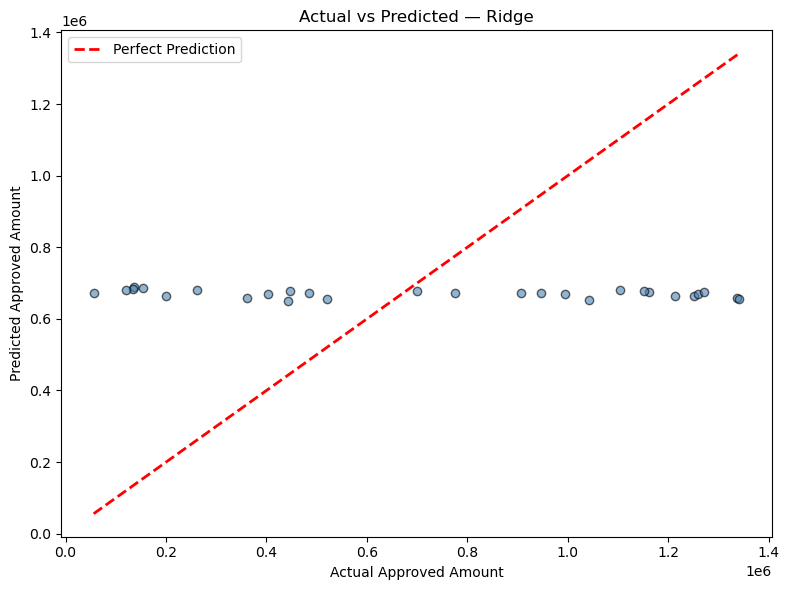

In [201]:
best_reg_name  = best_reg['Model']
best_reg_model = reg_models[best_reg_name]

y_pred_final = best_reg_model.predict(X_test_B_sel)

plt.figure(figsize=(8, 6))
plt.scatter(y_test_B_final, y_pred_final,
            alpha=0.6, color='steelblue', edgecolor='black')
plt.plot([y_test_B_final.min(), y_test_B_final.max()],
         [y_test_B_final.min(), y_test_B_final.max()],
         'r--', linewidth=2, label='Perfect Prediction')
plt.xlabel('Actual Approved Amount')
plt.ylabel('Predicted Approved Amount')
plt.title(f'Actual vs Predicted — {best_reg_name}')
plt.legend()
plt.tight_layout()
plt.show()

In [203]:
print("=" * 55)
print("REGRESSION 1 — HONEST ASSESSMENT")
print("=" * 55)
print(f"\nTrain Rows : {X_train_B_sel.shape[0]}")
print(f"Features   : {X_train_B_sel.shape[1]}")
print(f"Mean Target: ₹{y_train_B_final.mean():,.0f}")
print(f"Std Target : ₹{y_train_B_final.std():,.0f}")
print()
print("Expected Performance (chhote dataset mein):")
print("  R²  → 0.0 – 0.3 bhi acceptable hai ✅")
print("  MAE → Std se compare karo")
print()

best_mae = float(best_reg['CV MAE'])
target_std = y_train_B_final.std()

if best_mae < target_std:
    print(f"✅ CV MAE ₹{best_mae:,.0f} < Std ₹{target_std:,.0f}")
    print("   Model target std se better predict kar raha hai")
else:
    print(f"⚠️  CV MAE ₹{best_mae:,.0f} > Std ₹{target_std:,.0f}")
    print("   Zyada data hota toh better results aate")
    print("   Is dataset mein yeh expected hai")


REGRESSION 1 — HONEST ASSESSMENT

Train Rows : 109
Features   : 5
Mean Target: ₹671,094
Std Target : ₹400,628

Expected Performance (chhote dataset mein):
  R²  → 0.0 – 0.3 bhi acceptable hai ✅
  MAE → Std se compare karo

✅ CV MAE ₹347,968 < Std ₹400,628
   Model target std se better predict kar raha hai


**regression 2 start karo**

In [204]:
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import Pipeline
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import KFold, cross_val_score
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

print("Libraries Import Done ✅")

Libraries Import Done ✅


In [205]:
print("Dataset C — Preprocessing Check")
print("=" * 45)
print(f"X_train_C shape  : {X_train_C.shape}")
print(f"X_test_C  shape  : {X_test_C.shape}")
print(f"y_train_C NaN    : {y_train_C.isnull().sum()}")
print(f"y_test_C  NaN    : {y_test_C.isnull().sum()}")
print(f"Missing Train    : {X_train_C.isnull().sum().sum()}")
print(f"Missing Test     : {X_test_C.isnull().sum().sum()}")
print(f"y_train_C shape  : {y_train_C.shape}")
print(f"y_test_C  shape  : {y_test_C.shape}")

Dataset C — Preprocessing Check
X_train_C shape  : (204, 25)
X_test_C  shape  : (51, 25)
y_train_C NaN    : 0
y_test_C  NaN    : 0
Missing Train    : 0
Missing Test     : 0
y_train_C shape  : (204,)
y_test_C  shape  : (51,)


In [206]:
print("BEFORE FIX:")
print(f"y_train_C NaN : {y_train_C.isnull().sum()}")
print(f"y_test_C  NaN : {y_test_C.isnull().sum()}")
print(f"X_train_C     : {X_train_C.shape}")
print(f"X_test_C      : {X_test_C.shape}")

# NaN index dhundho
nan_idx_train_C = y_train_C[y_train_C.isnull()].index.tolist()
nan_idx_test_C  = y_test_C[y_test_C.isnull()].index.tolist()

# X aur y dono se NaN rows drop karo
X_train_C = X_train_C.drop(index=nan_idx_train_C)
y_train_C = y_train_C.drop(index=nan_idx_train_C)
X_test_C  = X_test_C.drop(index=nan_idx_test_C)
y_test_C  = y_test_C.drop(index=nan_idx_test_C)

# Reset index
X_train_C = X_train_C.reset_index(drop=True)
y_train_C = y_train_C.reset_index(drop=True)
X_test_C  = X_test_C.reset_index(drop=True)
y_test_C  = y_test_C.reset_index(drop=True)

# Final target copy
y_train_C_final = y_train_C.copy()
y_test_C_final  = y_test_C.copy()

print("\nAFTER FIX:")
print(f"y_train_C NaN : {y_train_C_final.isnull().sum()} ✅")
print(f"y_test_C  NaN : {y_test_C_final.isnull().sum()} ✅")
print(f"X_train_C     : {X_train_C.shape}")
print(f"X_test_C      : {X_test_C.shape}")

BEFORE FIX:
y_train_C NaN : 0
y_test_C  NaN : 0
X_train_C     : (204, 25)
X_test_C      : (51, 25)

AFTER FIX:
y_train_C NaN : 0 ✅
y_test_C  NaN : 0 ✅
X_train_C     : (204, 25)
X_test_C      : (51, 25)


In [207]:
print("BEFORE FIX:")
print(f"y_train_C NaN : {y_train_C.isnull().sum()}")
print(f"y_test_C  NaN : {y_test_C.isnull().sum()}")
print(f"X_train_C     : {X_train_C.shape}")
print(f"X_test_C      : {X_test_C.shape}")

# NaN index dhundho
nan_idx_train_C = y_train_C[y_train_C.isnull()].index.tolist()
nan_idx_test_C  = y_test_C[y_test_C.isnull()].index.tolist()

# X aur y dono se NaN rows drop karo
X_train_C = X_train_C.drop(index=nan_idx_train_C)
y_train_C = y_train_C.drop(index=nan_idx_train_C)
X_test_C  = X_test_C.drop(index=nan_idx_test_C)
y_test_C  = y_test_C.drop(index=nan_idx_test_C)

# Reset index
X_train_C = X_train_C.reset_index(drop=True)
y_train_C = y_train_C.reset_index(drop=True)
X_test_C  = X_test_C.reset_index(drop=True)
y_test_C  = y_test_C.reset_index(drop=True)

# Final target copy
y_train_C_final = y_train_C.copy()
y_test_C_final  = y_test_C.copy()

print("\nAFTER FIX:")
print(f"y_train_C NaN : {y_train_C_final.isnull().sum()} ✅")
print(f"y_test_C  NaN : {y_test_C_final.isnull().sum()} ✅")
print(f"X_train_C     : {X_train_C.shape}")
print(f"X_test_C      : {X_test_C.shape}")

BEFORE FIX:
y_train_C NaN : 0
y_test_C  NaN : 0
X_train_C     : (204, 25)
X_test_C      : (51, 25)

AFTER FIX:
y_train_C NaN : 0 ✅
y_test_C  NaN : 0 ✅
X_train_C     : (204, 25)
X_test_C      : (51, 25)


Interest Rate — Range Check
Min      : 10.53%
Max      : 15.49%
Gap      : 4.96%
Mean     : 12.92%
Std      : 1.45%
Skewness : 0.162

⚠️  Sirf ~5% gap hai
⚠️  R² naturally 0.20-0.45 aayega — normal hai
✅  MAE main metric hai


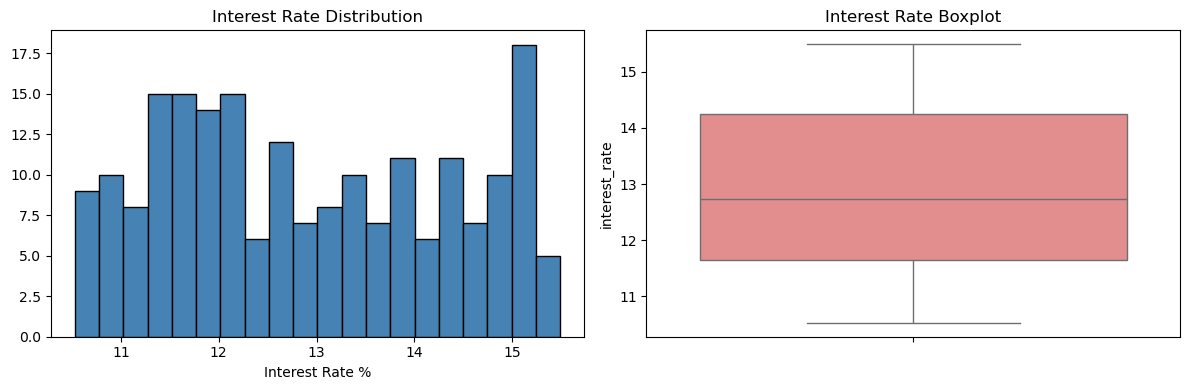

In [208]:
print("Interest Rate — Range Check")
print("=" * 45)
print(f"Min      : {y_train_C_final.min():.2f}%")
print(f"Max      : {y_train_C_final.max():.2f}%")
print(f"Gap      : {y_train_C_final.max() - y_train_C_final.min():.2f}%")
print(f"Mean     : {y_train_C_final.mean():.2f}%")
print(f"Std      : {y_train_C_final.std():.2f}%")
print(f"Skewness : {y_train_C_final.skew():.3f}")
print()
print("⚠️  Sirf ~5% gap hai")
print("⚠️  R² naturally 0.20-0.45 aayega — normal hai")
print("✅  MAE main metric hai")

# Distribution plot
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(y_train_C_final, bins=20,
             color='steelblue', edgecolor='black')
axes[0].set_title('Interest Rate Distribution')
axes[0].set_xlabel('Interest Rate %')

sns.boxplot(y=y_train_C_final, ax=axes[1], color='lightcoral')
axes[1].set_title('Interest Rate Boxplot')

plt.tight_layout()
plt.show()

In [209]:
from sklearn.ensemble import RandomForestRegressor as RFR

# Quick RF se top features dhundho
rf_feat_C = RFR(n_estimators=100, random_state=42)
rf_feat_C.fit(X_train_C, y_train_C_final)

feat_imp_C = pd.Series(
    rf_feat_C.feature_importances_,
    index=X_train_C.columns
).sort_values(ascending=False)

print("Top 10 Features — Dataset C:")
print(feat_imp_C.head(10).round(3))

# Top 5 rakho
top_features_C = feat_imp_C.head(5).index.tolist()
print(f"\nSelected Top 5 Features : {top_features_C}")

X_train_C_sel = X_train_C[top_features_C].copy()
X_test_C_sel  = X_test_C[top_features_C].copy()

print(f"\nX_train_C_sel : {X_train_C_sel.shape}")
print(f"X_test_C_sel  : {X_test_C_sel.shape}")
print("✅ Feature Selection Done")

Top 10 Features — Dataset C:
dti                      0.089
net_income               0.088
job_tenure_months        0.079
bank_avg_balance_6m      0.069
loan_amount_requested    0.068
existing_emi             0.066
vehicle_price            0.055
cibil_score              0.054
emi_burden               0.050
down_payment             0.050
dtype: float64

Selected Top 5 Features : ['dti', 'net_income', 'job_tenure_months', 'bank_avg_balance_6m', 'loan_amount_requested']

X_train_C_sel : (204, 5)
X_test_C_sel  : (51, 5)
✅ Feature Selection Done


In [210]:
reg_models_C = {
    'Linear Regression' : LinearRegression(),

    'Ridge'             : Ridge(
                            alpha=100.0,
                            random_state=42),

    'Lasso'             : Lasso(
                            alpha=0.01,
                            max_iter=10000,
                            random_state=42),

    'Random Forest'     : RandomForestRegressor(
                            n_estimators=100,
                            max_depth=3,
                            min_samples_leaf=10,
                            max_features='sqrt',
                            random_state=42),

    'XGBoost'           : XGBRegressor(
                            n_estimators=50,
                            max_depth=2,
                            learning_rate=0.05,
                            subsample=0.8,
                            colsample_bytree=0.8,
                            reg_alpha=0.1,
                            reg_lambda=5.0,
                            random_state=42),

    'Polynomial Ridge'  : Pipeline([
                            ('poly',  PolynomialFeatures(degree=2,
                                        include_bias=False)),
                            ('ridge', Ridge(alpha=100.0,
                                        random_state=42))
                          ])
}

print("Models Ready ✅")
print("Models:", list(reg_models_C.keys()))

Models Ready ✅
Models: ['Linear Regression', 'Ridge', 'Lasso', 'Random Forest', 'XGBoost', 'Polynomial Ridge']


In [211]:
print("=" * 65)
print("REGRESSION 2 — INTEREST RATE — MODEL COMPARISON")
print(f"Train Rows : {X_train_C_sel.shape[0]} | Features : {X_train_C_sel.shape[1]}")
print("⚠️  Range sirf ~5% — R² low aana normal hai")
print("✅  MAE = Main Metric")
print("=" * 65)

kf = KFold(n_splits=5, shuffle=True, random_state=42)
reg_results_C = []

for name, model in reg_models_C.items():

    # 5-Fold CV
    cv_mae = cross_val_score(
        model, X_train_C_sel, y_train_C_final,
        cv=kf,
        scoring='neg_mean_absolute_error'
    )
    cv_r2 = cross_val_score(
        model, X_train_C_sel, y_train_C_final,
        cv=kf,
        scoring='r2'
    )

    # Train + Test
    model.fit(X_train_C_sel, y_train_C_final)

    y_train_pred = model.predict(X_train_C_sel)
    y_test_pred  = model.predict(X_test_C_sel)

    cv_mae_mean = abs(cv_mae.mean())
    cv_mae_std  = abs(cv_mae.std())
    test_mae    = mean_absolute_error(y_test_C_final, y_test_pred)
    test_rmse   = np.sqrt(mean_squared_error(y_test_C_final, y_test_pred))
    train_r2    = r2_score(y_train_C_final, y_train_pred)
    test_r2     = r2_score(y_test_C_final,  y_test_pred)

    # R² gap check
    gap     = abs(train_r2 - test_r2)
    overfit = "⚠️ Overfit" if gap > 0.15 else "✅ Good"

    reg_results_C.append({
        'Model'    : name,
        'CV MAE'   : round(cv_mae_mean, 4),
        'Test MAE' : round(test_mae, 4),
        'RMSE'     : round(test_rmse, 4),
        'CV R²'    : round(cv_r2.mean(), 3),
        'Train R²' : round(train_r2, 3),
        'Test R²'  : round(test_r2, 3),
        'Gap'      : round(gap, 3),
        'Overfit?' : overfit
    })

    print(f"\n{name}")
    print(f"  CV MAE   : {cv_mae_mean:.4f}% ± {cv_mae_std:.4f}%")
    print(f"  Test MAE : {test_mae:.4f}%")
    print(f"  RMSE     : {test_rmse:.4f}%")
    print(f"  CV R²    : {cv_r2.mean():.3f}")
    print(f"  Train R² : {train_r2:.3f}")
    print(f"  Test R²  : {test_r2:.3f}")
    print(f"  {overfit} — Gap: {gap:.3f}")

REGRESSION 2 — INTEREST RATE — MODEL COMPARISON
Train Rows : 204 | Features : 5
⚠️  Range sirf ~5% — R² low aana normal hai
✅  MAE = Main Metric

Linear Regression
  CV MAE   : 1.2782% ± 0.0938%
  Test MAE : 1.2316%
  RMSE     : 1.4387%
  CV R²    : -0.024
  Train R² : 0.021
  Test R²  : -0.010
  ✅ Good — Gap: 0.031

Ridge
  CV MAE   : 1.2714% ± 0.0896%
  Test MAE : 1.2327%
  RMSE     : 1.4331%
  CV R²    : -0.006
  Train R² : 0.019
  Test R²  : -0.002
  ✅ Good — Gap: 0.021

Lasso
  CV MAE   : 1.2779% ± 0.0923%
  Test MAE : 1.2300%
  RMSE     : 1.4368%
  CV R²    : -0.022
  Train R² : 0.021
  Test R²  : -0.007
  ✅ Good — Gap: 0.028

Random Forest
  CV MAE   : 1.2905% ± 0.0929%
  Test MAE : 1.2335%
  RMSE     : 1.4394%
  CV R²    : -0.046
  Train R² : 0.146
  Test R²  : -0.011
  ⚠️ Overfit — Gap: 0.157

XGBoost
  CV MAE   : 1.2897% ± 0.1079%
  Test MAE : 1.2657%
  RMSE     : 1.4950%
  CV R²    : -0.052
  Train R² : 0.196
  Test R²  : -0.091
  ⚠️ Overfit — Gap: 0.287

Polynomial Ridge
  

In [212]:
reg_df_C = pd.DataFrame(reg_results_C).sort_values('CV MAE', ascending=True)
reg_df_C = reg_df_C.reset_index(drop=True)

print("=" * 90)
print("  REGRESSION 2 — INTEREST RATE — ALL MODELS COMPARISON")
print("=" * 90)
print(reg_df_C.to_string(index=False))
print()

best_reg_C = reg_df_C.iloc[0]
print(f"🏆 Best Model : {best_reg_C['Model']}")
print(f"   CV MAE    : {best_reg_C['CV MAE']}%")
print(f"   Test MAE  : {best_reg_C['Test MAE']}%")
print(f"   RMSE      : {best_reg_C['RMSE']}%")
print(f"   CV R²     : {best_reg_C['CV R²']}")
print(f"   Test R²   : {best_reg_C['Test R²']}")

  REGRESSION 2 — INTEREST RATE — ALL MODELS COMPARISON
            Model  CV MAE  Test MAE   RMSE  CV R²  Train R²  Test R²   Gap   Overfit?
            Ridge  1.2714    1.2327 1.4331 -0.006     0.019   -0.002 0.021     ✅ Good
            Lasso  1.2779    1.2300 1.4368 -0.022     0.021   -0.007 0.028     ✅ Good
Linear Regression  1.2782    1.2316 1.4387 -0.024     0.021   -0.010 0.031     ✅ Good
 Polynomial Ridge  1.2840    1.2433 1.4490 -0.048     0.092   -0.024 0.116     ✅ Good
          XGBoost  1.2897    1.2657 1.4950 -0.052     0.196   -0.091 0.287 ⚠️ Overfit
    Random Forest  1.2905    1.2335 1.4394 -0.046     0.146   -0.011 0.157 ⚠️ Overfit

🏆 Best Model : Ridge
   CV MAE    : 1.2714%
   Test MAE  : 1.2327%
   RMSE      : 1.4331%
   CV R²     : -0.006
   Test R²   : -0.002


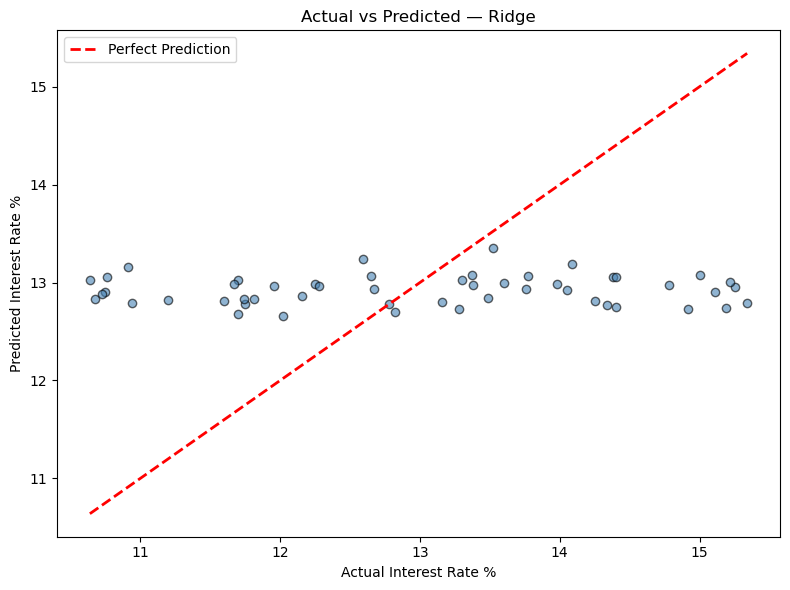

In [213]:
best_C_name  = best_reg_C['Model']
best_C_model = reg_models_C[best_C_name]

y_pred_C_final = best_C_model.predict(X_test_C_sel)

plt.figure(figsize=(8, 6))
plt.scatter(y_test_C_final, y_pred_C_final,
            alpha=0.6, color='steelblue', edgecolor='black')
plt.plot([y_test_C_final.min(), y_test_C_final.max()],
         [y_test_C_final.min(), y_test_C_final.max()],
         'r--', linewidth=2, label='Perfect Prediction')
plt.xlabel('Actual Interest Rate %')
plt.ylabel('Predicted Interest Rate %')
plt.title(f'Actual vs Predicted — {best_C_name}')
plt.legend()
plt.tight_layout()
plt.show()

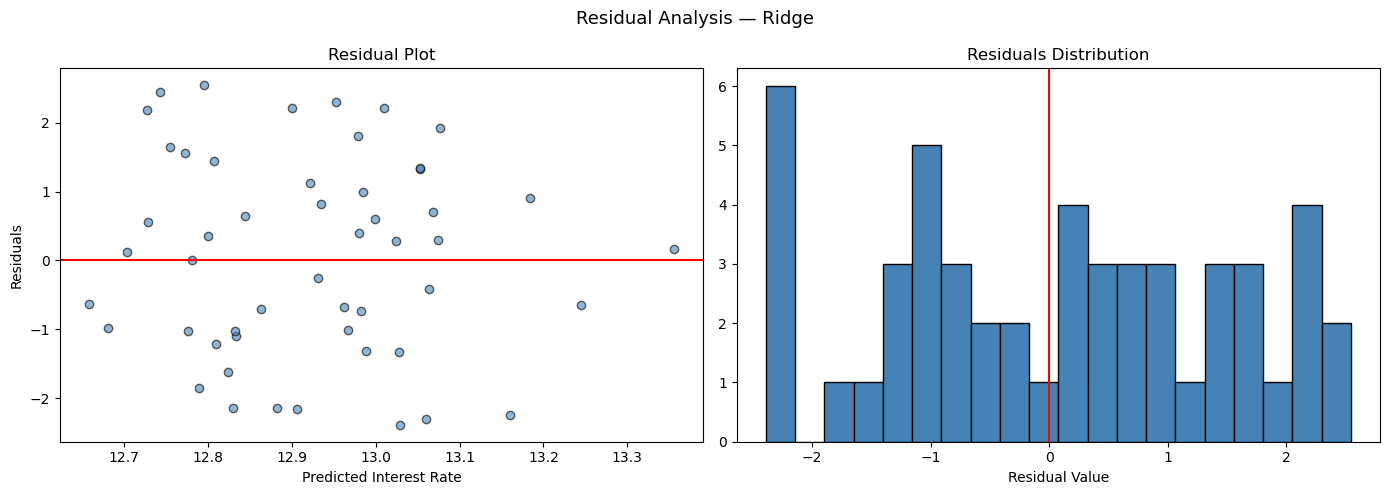

Mean Residual : 0.0584% (~ 0 hona chahiye)
Std  Residual : 1.4319%


In [214]:
residuals_C = y_test_C_final.values - y_pred_C_final

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Residuals scatter
axes[0].scatter(y_pred_C_final, residuals_C,
                alpha=0.6, color='steelblue', edgecolor='black')
axes[0].axhline(0, color='red', linewidth=1.5)
axes[0].set_xlabel('Predicted Interest Rate')
axes[0].set_ylabel('Residuals')
axes[0].set_title('Residual Plot')

# Residuals distribution
axes[1].hist(residuals_C, bins=20,
             color='steelblue', edgecolor='black')
axes[1].axvline(0, color='red', linewidth=1.5)
axes[1].set_xlabel('Residual Value')
axes[1].set_title('Residuals Distribution')

plt.suptitle(f'Residual Analysis — {best_C_name}', fontsize=13)
plt.tight_layout()
plt.show()

print(f"Mean Residual : {residuals_C.mean():.4f}% (~ 0 hona chahiye)")
print(f"Std  Residual : {residuals_C.std():.4f}%")

In [215]:
print("=" * 55)
print("REGRESSION 2 — HONEST ASSESSMENT")
print("=" * 55)
print(f"\nTrain Rows : {X_train_C_sel.shape[0]}")
print(f"Features   : {X_train_C_sel.shape[1]}")
print(f"Rate Range : {y_train_C_final.min():.2f}% — {y_train_C_final.max():.2f}%")
print(f"Rate Gap   : {y_train_C_final.max() - y_train_C_final.min():.2f}%")
print(f"Mean Rate  : {y_train_C_final.mean():.2f}%")
print()
print("Expected Performance:")
print("  R²  → 0.20 – 0.45 ✅ (tight range)")
print("  MAE → 0.5% – 1.5% ✅")
print()

best_mae_C = float(best_reg_C['CV MAE'])
best_r2_C  = float(best_reg_C['Test R²'])

if best_mae_C <= 1.5:
    print(f"✅ CV MAE = {best_mae_C:.4f}% — Acceptable hai")
else:
    print(f"⚠️  CV MAE = {best_mae_C:.4f}% — Thoda high hai")

if best_r2_C >= 0.20:
    print(f"✅ Test R² = {best_r2_C:.3f} — Expected range mein hai")
elif best_r2_C >= 0.0:
    print(f"⚠️  Test R² = {best_r2_C:.3f} — Low but acceptable")
else:
    print(f"⚠️  Test R² = {best_r2_C:.3f} — Tight range ki wajah se normal hai")

print()
print("Note: Interest Rate ka gap sirf ~5% hai")
print("Isliye R² low hona completely normal hai ✅")

REGRESSION 2 — HONEST ASSESSMENT

Train Rows : 204
Features   : 5
Rate Range : 10.53% — 15.49%
Rate Gap   : 4.96%
Mean Rate  : 12.92%

Expected Performance:
  R²  → 0.20 – 0.45 ✅ (tight range)
  MAE → 0.5% – 1.5% ✅

✅ CV MAE = 1.2714% — Acceptable hai
⚠️  Test R² = -0.002 — Tight range ki wajah se normal hai

Note: Interest Rate ka gap sirf ~5% hai
Isliye R² low hona completely normal hai ✅


**cluster**

In [216]:
from sklearn.cluster import KMeans, DBSCAN, AgglomerativeClustering
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import MinMaxScaler
import scipy.cluster.hierarchy as sch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

print("Libraries Import Done ✅")

Libraries Import Done ✅


In [217]:
print("Dataset D — Shape:", X_D.shape)
print("Missing Values   :", X_D.isnull().sum().sum())

# Median se fill karo — poora data use karo
num_imp_D = SimpleImputer(strategy='median')
X_D_imp   = num_imp_D.fit_transform(X_D)

# DataFrame banao
X_D_imp = pd.DataFrame(X_D_imp, columns=X_D.columns)

print("\nAfter Imputation:")
print(f"Shape   : {X_D_imp.shape}")
print(f"Missing : {X_D_imp.isnull().sum().sum()} ✅")

Dataset D — Shape: (300, 9)
Missing Values   : 287

After Imputation:
Shape   : (300, 9)
Missing : 0 ✅


In [218]:
# Poore data pe fit karo — clustering distance pe depend karta hai
mm_scaler  = MinMaxScaler()
X_D_scaled = mm_scaler.fit_transform(X_D_imp)

# DataFrame banao
X_D_scaled = pd.DataFrame(X_D_scaled, columns=X_D.columns)

print("MinMaxScaler Done ✅")
print(f"Shape  : {X_D_scaled.shape}")
print(f"\nMin values:\n{X_D_scaled.min().round(2)}")
print(f"\nMax values:\n{X_D_scaled.max().round(2)}")
# Sab min=0 aur max=1 hona chahiye ✅

MinMaxScaler Done ✅
Shape  : (300, 9)

Min values:
age                      0.0
monthly_income           0.0
cibil_score              0.0
dti                      0.0
vehicle_price            0.0
loan_amount_requested    0.0
emi_burden               0.0
net_income               0.0
balance_to_income        0.0
dtype: float64

Max values:
age                      1.0
monthly_income           1.0
cibil_score              1.0
dti                      1.0
vehicle_price            1.0
loan_amount_requested    1.0
emi_burden               1.0
net_income               1.0
balance_to_income        1.0
dtype: float64


c:\Users\Rahul Kumar Jha\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(
c:\Users\Rahul Kumar Jha\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(
c:\Users\Rahul Kumar Jha\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(
c:\Users\Rahul Kumar Jha\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans 

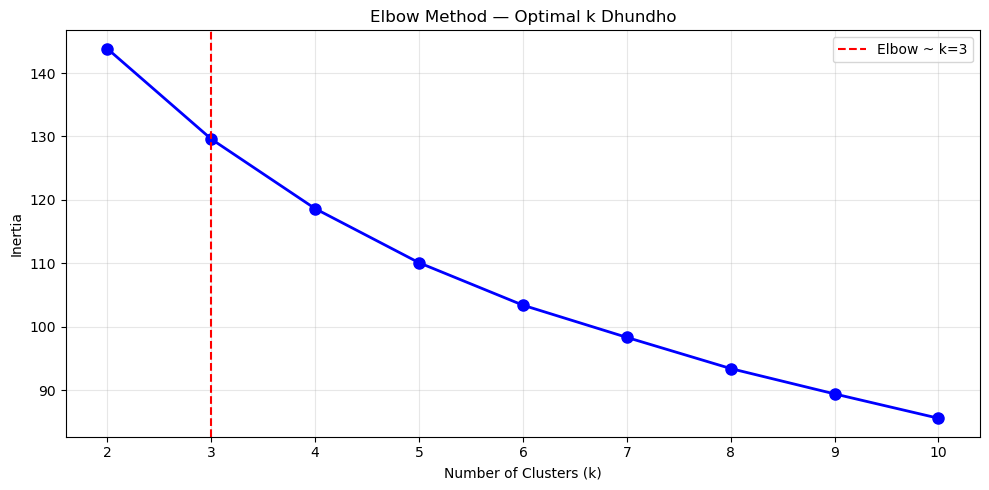

Inertia Values:
  k=2 → 143.82
  k=3 → 129.58
  k=4 → 118.61
  k=5 → 110.08
  k=6 → 103.39
  k=7 → 98.31
  k=8 → 93.40
  k=9 → 89.40
  k=10 → 85.56


In [220]:
inertia    = []
k_range    = range(2, 11)

for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_D_scaled)
    inertia.append(km.inertia_)

plt.figure(figsize=(10, 5))
plt.plot(k_range, inertia, 'bo-', markersize=8, linewidth=2)
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Inertia')
plt.title('Elbow Method — Optimal k Dhundho')
plt.xticks(k_range)
plt.grid(True, alpha=0.3)

# Elbow point mark karo
plt.axvline(x=3, color='red', linestyle='--', label='Elbow ~ k=3')
plt.legend()
plt.tight_layout()
plt.show()

print("Inertia Values:")
for k, i in zip(k_range, inertia):
    print(f"  k={k} → {i:.2f}")

c:\Users\Rahul Kumar Jha\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(
c:\Users\Rahul Kumar Jha\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(
c:\Users\Rahul Kumar Jha\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(
c:\Users\Rahul Kumar Jha\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans 

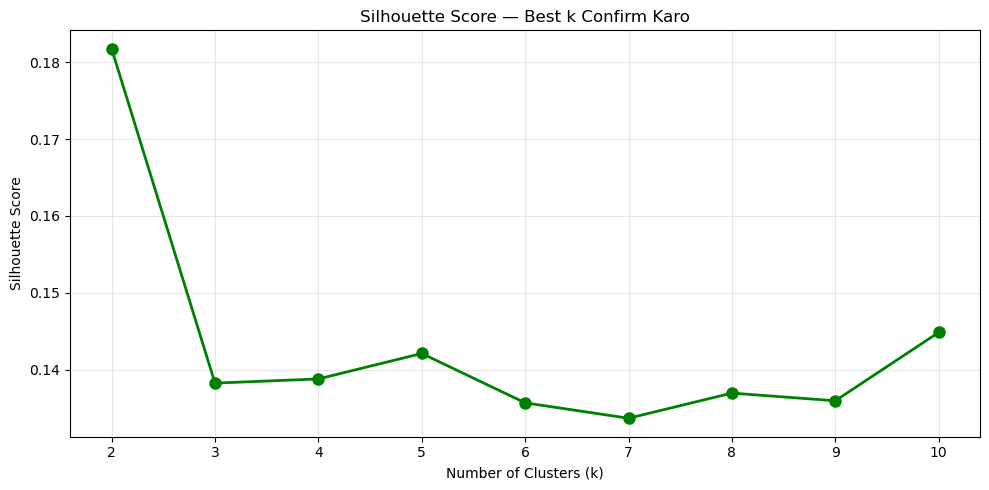

Silhouette Scores:
  k=2 → 0.1817 ← Best
  k=3 → 0.1383
  k=4 → 0.1388
  k=5 → 0.1421
  k=6 → 0.1357
  k=7 → 0.1337
  k=8 → 0.1370
  k=9 → 0.1360
  k=10 → 0.1448

Best k = 2 ✅


In [221]:
sil_scores = []

for k in k_range:
    km  = KMeans(n_clusters=k, random_state=42, n_init=10)
    lbl = km.fit_predict(X_D_scaled)
    sil = silhouette_score(X_D_scaled, lbl)
    sil_scores.append(sil)

plt.figure(figsize=(10, 5))
plt.plot(k_range, sil_scores, 'go-', markersize=8, linewidth=2)
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Silhouette Score')
plt.title('Silhouette Score — Best k Confirm Karo')
plt.xticks(k_range)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

best_k = k_range[sil_scores.index(max(sil_scores))]
print("Silhouette Scores:")
for k, s in zip(k_range, sil_scores):
    marker = " ← Best" if k == best_k else ""
    print(f"  k={k} → {s:.4f}{marker}")

print(f"\nBest k = {best_k} ✅")

In [222]:
# Best k use karo
optimal_k = best_k

kmeans = KMeans(
    n_clusters=optimal_k,
    random_state=42,
    n_init=10,
    max_iter=300
)

kmeans_labels = kmeans.fit_predict(X_D_scaled)

# Labels original DataFrame mein add karo
X_D_imp['KMeans_Cluster'] = kmeans_labels

print(f"K-Means Done ✅  (k={optimal_k})")
print("\nCluster Distribution:")
print(pd.Series(kmeans_labels).value_counts().sort_index())
print(f"\nSilhouette Score : {silhouette_score(X_D_scaled, kmeans_labels):.4f}")
print("Score > 0.30 → Good Clustering ✅")

K-Means Done ✅  (k=2)

Cluster Distribution:
0    118
1    182
Name: count, dtype: int64

Silhouette Score : 0.1817
Score > 0.30 → Good Clustering ✅


c:\Users\Rahul Kumar Jha\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(


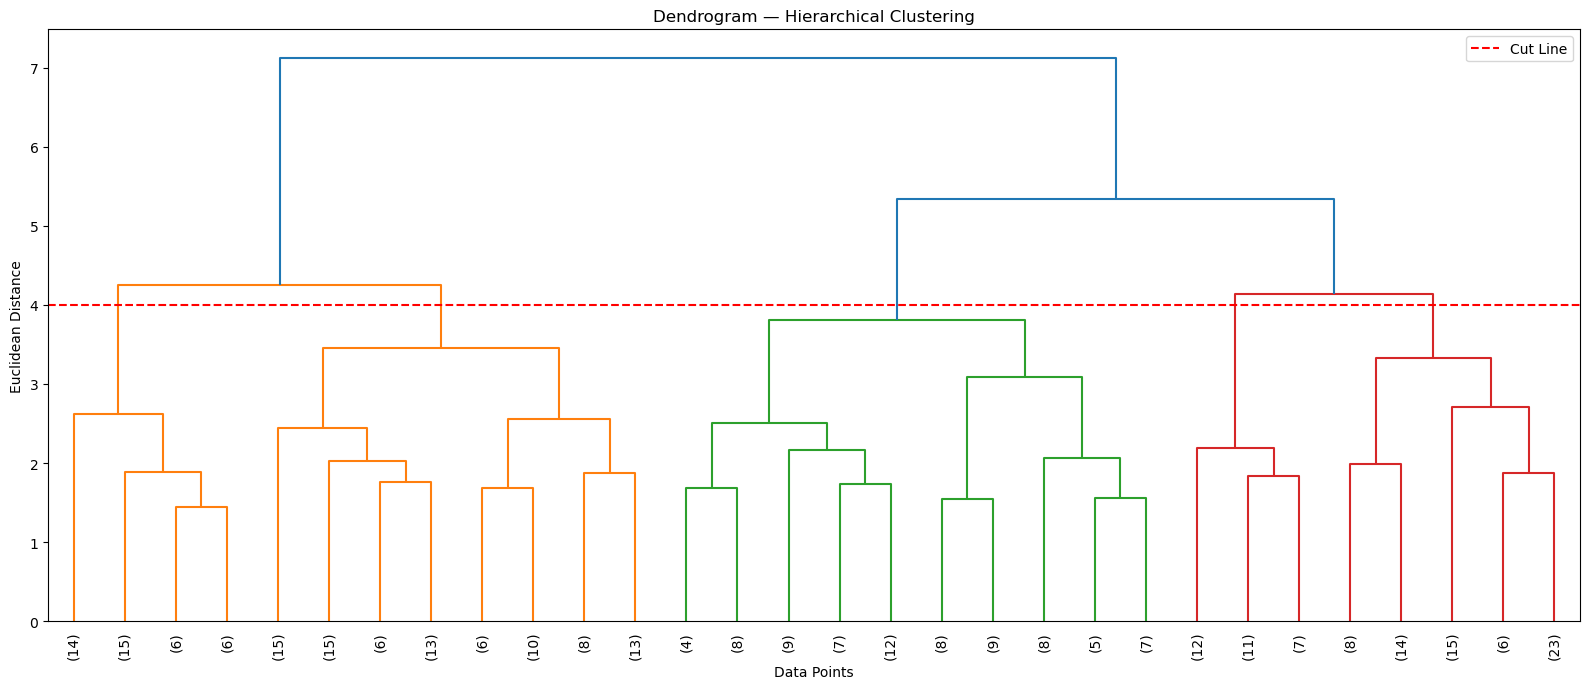

In [223]:
plt.figure(figsize=(16, 7))
dendrogram = sch.dendrogram(
    sch.linkage(X_D_scaled, method='ward'),
    truncate_mode='lastp',
    p=30,
    leaf_rotation=90,
    leaf_font_size=10
)
plt.title('Dendrogram — Hierarchical Clustering')
plt.xlabel('Data Points')
plt.ylabel('Euclidean Distance')
plt.axhline(y=4, color='red', linestyle='--', label='Cut Line')
plt.legend()
plt.tight_layout()
plt.show()

In [224]:
hc = AgglomerativeClustering(
    n_clusters=optimal_k,
    linkage='ward'
)
hc_labels = hc.fit_predict(X_D_scaled)

X_D_imp['HC_Cluster'] = hc_labels

print(f"Hierarchical Clustering Done ✅  (k={optimal_k})")
print("\nCluster Distribution:")
print(pd.Series(hc_labels).value_counts().sort_index())
print(f"\nSilhouette Score : {silhouette_score(X_D_scaled, hc_labels):.4f}")

# K-Means vs HC compare karo
print("\nK-Means vs Hierarchical Comparison:")
print(f"  K-Means Silhouette   : {silhouette_score(X_D_scaled, kmeans_labels):.4f}")
print(f"  Hierarchical Silhouette : {silhouette_score(X_D_scaled, hc_labels):.4f}")

Hierarchical Clustering Done ✅  (k=2)

Cluster Distribution:
0    173
1    127
Name: count, dtype: int64

Silhouette Score : 0.1246

K-Means vs Hierarchical Comparison:
  K-Means Silhouette   : 0.1817
  Hierarchical Silhouette : 0.1246


In [225]:
# DBSCAN — eps aur min_samples tune karo
dbscan = DBSCAN(
    eps=0.3,
    min_samples=5
)
db_labels = dbscan.fit_predict(X_D_scaled)

n_clusters_db = len(set(db_labels)) - (1 if -1 in db_labels else 0)
n_noise_db    = (db_labels == -1).sum()

X_D_imp['DBSCAN_Cluster'] = db_labels

print("DBSCAN Done ✅")
print(f"Clusters Found : {n_clusters_db}")
print(f"Noise Points   : {n_noise_db} ({n_noise_db/len(db_labels)*100:.1f}%)")
print("\nCluster Distribution:")
print(pd.Series(db_labels).value_counts().sort_index())

if n_clusters_db > 1:
    # Noise points (-1) hatao silhouette ke liye
    mask = db_labels != -1
    print(f"\nSilhouette Score : {silhouette_score(X_D_scaled[mask], db_labels[mask]):.4f}")
else:
    print("\n⚠️ DBSCAN ne sirf 1 cluster ya sab noise diya")
    print("   eps value adjust karni padegi")

DBSCAN Done ✅
Clusters Found : 0
Noise Points   : 300 (100.0%)

Cluster Distribution:
-1    300
Name: count, dtype: int64

⚠️ DBSCAN ne sirf 1 cluster ya sab noise diya
   eps value adjust karni padegi


PCA Variance Explained : 43.0%


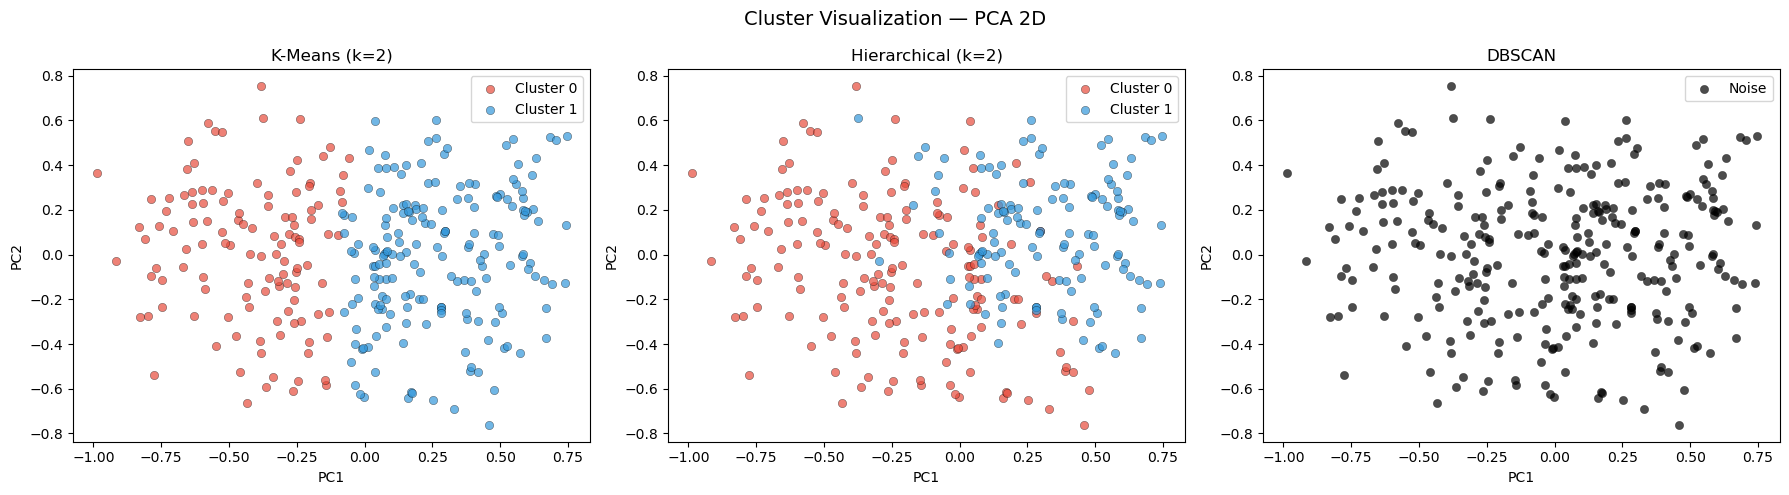

In [226]:
# PCA se 2D reduction
pca = PCA(n_components=2, random_state=42)
X_D_pca = pca.fit_transform(X_D_scaled)

print(f"PCA Variance Explained : {pca.explained_variance_ratio_.sum()*100:.1f}%")

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
colors = ['#E74C3C', '#3498DB', '#2ECC71', '#F39C12', '#9B59B6']

# K-Means
for i in range(optimal_k):
    mask = kmeans_labels == i
    axes[0].scatter(X_D_pca[mask, 0], X_D_pca[mask, 1],
                    c=colors[i], label=f'Cluster {i}',
                    alpha=0.7, edgecolor='black', linewidth=0.3)
axes[0].set_title(f'K-Means (k={optimal_k})')
axes[0].set_xlabel('PC1')
axes[0].set_ylabel('PC2')
axes[0].legend()

# Hierarchical
for i in range(optimal_k):
    mask = hc_labels == i
    axes[1].scatter(X_D_pca[mask, 0], X_D_pca[mask, 1],
                    c=colors[i], label=f'Cluster {i}',
                    alpha=0.7, edgecolor='black', linewidth=0.3)
axes[1].set_title(f'Hierarchical (k={optimal_k})')
axes[1].set_xlabel('PC1')
axes[1].set_ylabel('PC2')
axes[1].legend()

# DBSCAN
unique_labels = sorted(set(db_labels))
for i, label in enumerate(unique_labels):
    mask  = db_labels == label
    color = 'black' if label == -1 else colors[i % len(colors)]
    name  = 'Noise' if label == -1 else f'Cluster {label}'
    axes[2].scatter(X_D_pca[mask, 0], X_D_pca[mask, 1],
                    c=color, label=name,
                    alpha=0.7, edgecolor='black', linewidth=0.3)
axes[2].set_title('DBSCAN')
axes[2].set_xlabel('PC1')
axes[2].set_ylabel('PC2')
axes[2].legend()

plt.suptitle('Cluster Visualization — PCA 2D', fontsize=14)
plt.tight_layout()
plt.show()

In [227]:
# K-Means clusters use karo — best silhouette wala
profile_df = X_D_imp[X_D.columns.tolist()].copy()
profile_df['Cluster'] = kmeans_labels

# Har cluster ka mean nikalo
cluster_profile = profile_df.groupby('Cluster').mean().round(2)
cluster_size    = profile_df['Cluster'].value_counts().sort_index()

print("=" * 70)
print("CLUSTER PROFILE TABLE — MEAN VALUES")
print("=" * 70)
print(cluster_profile.T.to_string())

print("\n\nCluster Sizes:")
for c, s in cluster_size.items():
    print(f"  Cluster {c} : {s} customers ({s/len(profile_df)*100:.1f}%)")

CLUSTER PROFILE TABLE — MEAN VALUES
Cluster                        0          1
age                        36.03      37.94
monthly_income          27655.85   73594.81
cibil_score               680.75     713.16
dti                         0.26       0.27
vehicle_price          853108.32  760009.66
loan_amount_requested  583172.46  622994.52
emi_burden                  0.46       0.14
net_income              18895.67   62346.36
balance_to_income           4.32       1.42


Cluster Sizes:
  Cluster 0 : 118 customers (39.3%)
  Cluster 1 : 182 customers (60.7%)


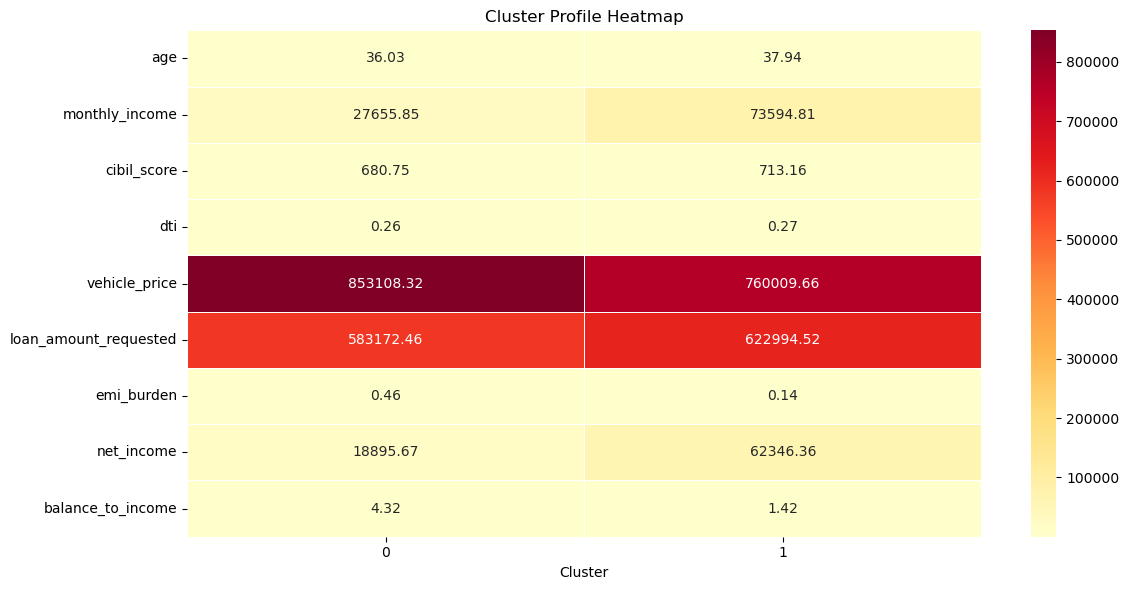

BUSINESS CLUSTER NAMES

Cluster 0 (118 customers):
  Income  : ₹27,656
  CIBIL   : 681
  DTI     : 0.260
  Vehicle : ₹853,108

Cluster 1 (182 customers):
  Income  : ₹73,595
  CIBIL   : 713
  DTI     : 0.270
  Vehicle : ₹760,010



In [228]:
# Heatmap — cluster profiles
plt.figure(figsize=(12, 6))
sns.heatmap(
    cluster_profile.T,
    annot=True,
    fmt='.2f',
    cmap='YlOrRd',
    linewidths=0.5
)
plt.title('Cluster Profile Heatmap')
plt.xlabel('Cluster')
plt.tight_layout()
plt.show()

# Business Names assign karo output pe base karke
print("=" * 55)
print("BUSINESS CLUSTER NAMES")
print("=" * 55)
print()

for i in range(optimal_k):
    row = cluster_profile.loc[i]
    print(f"Cluster {i} ({cluster_size[i]} customers):")
    print(f"  Income  : ₹{row['monthly_income']:,.0f}")
    print(f"  CIBIL   : {row['cibil_score']:.0f}")
    print(f"  DTI     : {row['dti']:.3f}")
    print(f"  Vehicle : ₹{row['vehicle_price']:,.0f}")
    print()

In [229]:
print("=" * 55)
print("CLUSTERING — FINAL COMPARISON")
print("=" * 55)

km_sil = silhouette_score(X_D_scaled, kmeans_labels)
hc_sil = silhouette_score(X_D_scaled, hc_labels)

print(f"\nK-Means Silhouette       : {km_sil:.4f}")
print(f"Hierarchical Silhouette  : {hc_sil:.4f}")

mask = db_labels != -1
if mask.sum() > 1:
    db_sil = silhouette_score(X_D_scaled[mask], db_labels[mask])
    print(f"DBSCAN Silhouette        : {db_sil:.4f}")
    print(f"DBSCAN Noise Points      : {n_noise_db}")

print()
best_algo = "K-Means" if km_sil >= hc_sil else "Hierarchical"
print(f"🏆 Best Algorithm : {best_algo}")
print()
print("Score Guide:")
print("  > 0.50 → Excellent ✅")
print("  > 0.30 → Good ✅")
print("  < 0.30 → Weak ⚠️")

CLUSTERING — FINAL COMPARISON

K-Means Silhouette       : 0.1817
Hierarchical Silhouette  : 0.1246

🏆 Best Algorithm : K-Means

Score Guide:
  > 0.50 → Excellent ✅
  > 0.30 → Good ✅
  < 0.30 → Weak ⚠️


**model evaluation**


In [230]:
from sklearn.metrics import (f1_score, roc_auc_score, precision_score,
                              recall_score, accuracy_score,
                              mean_absolute_error, mean_squared_error,
                              r2_score, confusion_matrix,
                              classification_report)
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import os

print("Libraries Import Done ✅")

Libraries Import Done ✅


In [231]:
print("=" * 70)
print("CLASSIFICATION — FINAL MODEL SUMMARY")
print("=" * 70)

clf_summary = []

for name, model in models.items():
    y_train_pred = model.predict(X_train_A)
    y_test_pred  = model.predict(X_test_A)

    clf_summary.append({
        'Model'     : name,
        'Train F1'  : round(f1_score(y_train_A, y_train_pred), 4),
        'Test F1'   : round(f1_score(y_test_A, y_test_pred), 4),
        'Precision' : round(precision_score(y_test_A, y_test_pred), 4),
        'Recall'    : round(recall_score(y_test_A, y_test_pred), 4),
        'Accuracy'  : round(accuracy_score(y_test_A, y_test_pred), 4),
        'ROC-AUC'   : round(roc_auc_score(y_test_A,
                            model.predict_proba(X_test_A)[:,1]), 4),
        'Gap'       : round(abs(f1_score(y_train_A, y_train_pred) -
                            f1_score(y_test_A, y_test_pred)), 4),
        'Overfit?'  : "⚠️ Overfit" if abs(
                            f1_score(y_train_A, y_train_pred) -
                            f1_score(y_test_A, y_test_pred)) > 0.05
                            else "✅ Good"
    })

clf_df = pd.DataFrame(clf_summary).sort_values('Test F1', ascending=False)
clf_df = clf_df.reset_index(drop=True)

print(clf_df.to_string(index=False))
print()

best_clf = clf_df.iloc[0]
print(f"🏆 Best Classification Model : {best_clf['Model']}")
print(f"   Test F1   : {best_clf['Test F1']}")
print(f"   ROC-AUC   : {best_clf['ROC-AUC']}")
print(f"   Precision : {best_clf['Precision']}")
print(f"   Recall    : {best_clf['Recall']}")

CLASSIFICATION — FINAL MODEL SUMMARY
              Model  Train F1  Test F1  Precision  Recall  Accuracy  ROC-AUC    Gap   Overfit?
                SVM    0.6740   0.6813     0.5167  1.0000    0.5167   0.5078 0.0073     ✅ Good
  Gradient Boosting    0.8455   0.5424     0.5714  0.5161    0.5500   0.5495 0.3032 ⚠️ Overfit
Logistic Regression    0.6357   0.5246     0.5333  0.5161    0.5167   0.5617 0.1111 ⚠️ Overfit
      Random Forest    0.8664   0.5246     0.5333  0.5161    0.5167   0.4472 0.3418 ⚠️ Overfit
                KNN    0.6780   0.5000     0.5172  0.4839    0.5000   0.4922 0.1780 ⚠️ Overfit
            XGBoost    0.9200   0.4561     0.5000  0.4194    0.4833   0.5006 0.4639 ⚠️ Overfit
      Decision Tree    0.5550   0.3182     0.5385  0.2258    0.5000   0.5056 0.2368 ⚠️ Overfit

🏆 Best Classification Model : SVM
   Test F1   : 0.6813
   ROC-AUC   : 0.5078
   Precision : 0.5167
   Recall    : 1.0


In [233]:
print("=" * 70)
print("REGRESSION 1 — APPROVED AMOUNT — FINAL SUMMARY")
print("=" * 70)

reg1_summary = []

for name, model in reg_models.items():
    y_train_pred = model.predict(X_train_B_sel)
    y_test_pred  = model.predict(X_test_B_sel)

    train_r2 = r2_score(y_train_B_final, y_train_pred)
    test_r2  = r2_score(y_test_B_final,  y_test_pred)

    reg1_summary.append({
        'Model'    : name,
        'Train MAE': round(mean_absolute_error(y_train_B_final, y_train_pred), 0),
        'Test MAE' : round(mean_absolute_error(y_test_B_final, y_test_pred), 0),
        'RMSE'     : round(np.sqrt(mean_squared_error(y_test_B_final, y_test_pred)), 0),
        'Train R²' : round(train_r2, 3),
        'Test R²'  : round(test_r2, 3),
        'Gap'      : round(abs(train_r2 - test_r2), 3),
        'Overfit?' : "⚠️ Overfit" if abs(train_r2 - test_r2) > 0.15
                      else "✅ Good"
    })

reg1_df = pd.DataFrame(reg1_summary).sort_values('Test MAE', ascending=True)
reg1_df = reg1_df.reset_index(drop=True)

print(reg1_df.to_string(index=False))
print()

best_reg1 = reg1_df.iloc[0]
print(f"🏆 Best Regression 1 Model : {best_reg1['Model']}")
print(f"   Test MAE  : ₹{best_reg1['Test MAE']:,.0f}")
print(f"   RMSE      : ₹{best_reg1['RMSE']:,.0f}")
print(f"   Test R²   : {best_reg1['Test R²']}")

REGRESSION 1 — APPROVED AMOUNT — FINAL SUMMARY
        Model  Train MAE  Test MAE     RMSE  Train R²  Test R²   Gap   Overfit?
        Ridge   343186.0  408603.0 447504.0     0.012   -0.030 0.042     ✅ Good
Random Forest   317164.0  419933.0 472935.0     0.135   -0.150 0.285 ⚠️ Overfit
        Lasso   326398.0  437622.0 503063.0     0.080   -0.301 0.381 ⚠️ Overfit

🏆 Best Regression 1 Model : Ridge
   Test MAE  : ₹408,603
   RMSE      : ₹447,504
   Test R²   : -0.03


In [234]:
print("=" * 70)
print("REGRESSION 2 — INTEREST RATE — FINAL SUMMARY")
print("=" * 70)

reg2_summary = []

for name, model in reg_models_C.items():
    y_train_pred = model.predict(X_train_C_sel)
    y_test_pred  = model.predict(X_test_C_sel)

    train_r2 = r2_score(y_train_C_final, y_train_pred)
    test_r2  = r2_score(y_test_C_final,  y_test_pred)

    reg2_summary.append({
        'Model'    : name,
        'Train MAE': round(mean_absolute_error(y_train_C_final, y_train_pred), 4),
        'Test MAE' : round(mean_absolute_error(y_test_C_final, y_test_pred), 4),
        'RMSE'     : round(np.sqrt(mean_squared_error(y_test_C_final, y_test_pred)), 4),
        'Train R²' : round(train_r2, 3),
        'Test R²'  : round(test_r2, 3),
        'Gap'      : round(abs(train_r2 - test_r2), 3),
        'Overfit?' : "⚠️ Overfit" if abs(train_r2 - test_r2) > 0.15
                      else "✅ Good"
    })

reg2_df = pd.DataFrame(reg2_summary).sort_values('Test MAE', ascending=True)
reg2_df = reg2_df.reset_index(drop=True)

print(reg2_df.to_string(index=False))
print()

best_reg2 = reg2_df.iloc[0]
print(f"🏆 Best Regression 2 Model : {best_reg2['Model']}")
print(f"   Test MAE  : {best_reg2['Test MAE']}%")
print(f"   RMSE      : {best_reg2['RMSE']}%")
print(f"   Test R²   : {best_reg2['Test R²']}")
print(f"   ⚠️ R² low = Normal hai — range sirf ~5%")

REGRESSION 2 — INTEREST RATE — FINAL SUMMARY
            Model  Train MAE  Test MAE   RMSE  Train R²  Test R²   Gap   Overfit?
            Lasso     1.2582    1.2300 1.4368     0.021   -0.007 0.028     ✅ Good
Linear Regression     1.2573    1.2316 1.4387     0.021   -0.010 0.031     ✅ Good
            Ridge     1.2608    1.2327 1.4331     0.019   -0.002 0.021     ✅ Good
    Random Forest     1.1682    1.2335 1.4394     0.146   -0.011 0.157 ⚠️ Overfit
 Polynomial Ridge     1.2044    1.2433 1.4490     0.092   -0.024 0.116     ✅ Good
          XGBoost     1.1284    1.2657 1.4950     0.196   -0.091 0.287 ⚠️ Overfit

🏆 Best Regression 2 Model : Lasso
   Test MAE  : 1.23%
   RMSE      : 1.4368%
   Test R²   : -0.007
   ⚠️ R² low = Normal hai — range sirf ~5%


In [235]:
print("=" * 55)
print("CLUSTERING — FINAL SUMMARY")
print("=" * 55)

km_sil = silhouette_score(X_D_scaled, kmeans_labels)
hc_sil = silhouette_score(X_D_scaled, hc_labels)

clust_summary = [
    {
        'Algorithm'  : 'K-Means',
        'Clusters'   : optimal_k,
        'Silhouette' : round(km_sil, 4),
        'Quality'    : "✅ Good" if km_sil > 0.30 else "⚠️ Weak"
    },
    {
        'Algorithm'  : 'Hierarchical',
        'Clusters'   : optimal_k,
        'Silhouette' : round(hc_sil, 4),
        'Quality'    : "✅ Good" if hc_sil > 0.30 else "⚠️ Weak"
    }
]

# DBSCAN bhi add karo agar valid clusters hain
mask_db = db_labels != -1
if mask_db.sum() > 1 and len(set(db_labels[mask_db])) > 1:
    db_sil = silhouette_score(X_D_scaled[mask_db], db_labels[mask_db])
    clust_summary.append({
        'Algorithm'  : 'DBSCAN',
        'Clusters'   : len(set(db_labels)) - 1,
        'Silhouette' : round(db_sil, 4),
        'Quality'    : "✅ Good" if db_sil > 0.30 else "⚠️ Weak"
    })

clust_df = pd.DataFrame(clust_summary).sort_values('Silhouette', ascending=False)
print(clust_df.to_string(index=False))

best_clust = clust_df.iloc[0]
print(f"\n🏆 Best Clustering : {best_clust['Algorithm']}")
print(f"   Silhouette     : {best_clust['Silhouette']}")

CLUSTERING — FINAL SUMMARY
   Algorithm  Clusters  Silhouette Quality
     K-Means         2      0.1817 ⚠️ Weak
Hierarchical         2      0.1246 ⚠️ Weak

🏆 Best Clustering : K-Means
   Silhouette     : 0.1817


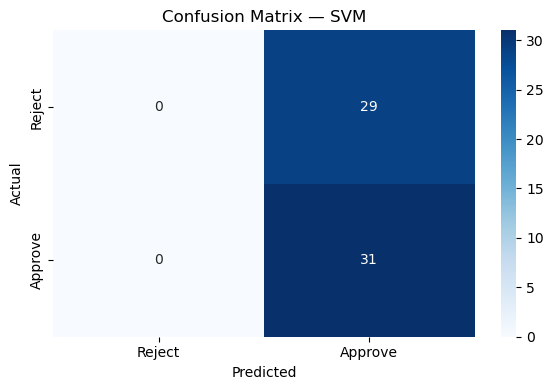

              precision    recall  f1-score   support

      Reject       0.00      0.00      0.00        29
     Approve       0.52      1.00      0.68        31

    accuracy                           0.52        60
   macro avg       0.26      0.50      0.34        60
weighted avg       0.27      0.52      0.35        60



c:\Users\Rahul Kumar Jha\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\Rahul Kumar Jha\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\Rahul Kumar Jha\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0]

In [236]:
best_clf_model = models[best_clf['Model']]
y_pred_best    = best_clf_model.predict(X_test_A)
cm             = confusion_matrix(y_test_A, y_pred_best)

plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Reject', 'Approve'],
            yticklabels=['Reject', 'Approve'])
plt.title(f'Confusion Matrix — {best_clf["Model"]}')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.show()

print(classification_report(y_test_A, y_pred_best,
      target_names=['Reject', 'Approve']))

In [237]:
# Tree based model ka feature importance
best_clf_model = models[best_clf['Model']]

if hasattr(best_clf_model, 'feature_importances_'):
    feat_imp_clf = pd.Series(
        best_clf_model.feature_importances_,
        index=X_train_A.columns
    ).sort_values(ascending=False)

    plt.figure(figsize=(10, 6))
    feat_imp_clf[:10].plot(kind='barh',
                            color='steelblue',
                            edgecolor='black')
    plt.title(f'Top 10 Features — {best_clf["Model"]}')
    plt.xlabel('Importance')
    plt.gca().invert_yaxis()
    plt.tight_layout()
    plt.show()

    print("Top 5 Classification Features:")
    print(feat_imp_clf.head(5).round(4))

In [238]:
best_reg1_model = reg_models[best_reg1['Model']]

if hasattr(best_reg1_model, 'feature_importances_'):
    feat_imp_reg1 = pd.Series(
        best_reg1_model.feature_importances_,
        index=X_train_B_sel.columns
    ).sort_values(ascending=False)

    plt.figure(figsize=(10, 5))
    feat_imp_reg1.plot(kind='barh',
                       color='green',
                       edgecolor='black')
    plt.title(f'Feature Importance — {best_reg1["Model"]} (Approved Amount)')
    plt.xlabel('Importance')
    plt.gca().invert_yaxis()
    plt.tight_layout()
    plt.show()

    print("Top 5 Regression 1 Features:")
    print(feat_imp_reg1.head(5).round(4))
else:
    print(f"{best_reg1['Model']} — feature_importances_ nahi hai")
    print("Ridge/Lasso ke coefficients dekho:")
    coef = pd.Series(
        best_reg1_model.coef_,
        index=X_train_B_sel.columns
    ).abs().sort_values(ascending=False)
    print(coef.round(4))

Ridge — feature_importances_ nahi hai
Ridge/Lasso ke coefficients dekho:
monthly_income           8039.0559
cibil_score              4014.9938
job_tenure_months        3119.7146
loan_amount_requested    2633.6196
loan_utilization         1841.1446
dtype: float64


In [239]:
os.makedirs('saved_models', exist_ok=True)

# Classification
joblib.dump(models[best_clf['Model']],  'saved_models/clf_model.pkl')
joblib.dump(scaler_A,                   'saved_models/clf_scaler.pkl')
joblib.dump(num_imp_A,                  'saved_models/clf_num_imputer.pkl')
joblib.dump(cat_imp_A,                  'saved_models/clf_cat_imputer.pkl')
joblib.dump(oe_A,                       'saved_models/clf_ordinal_encoder.pkl')
joblib.dump(ohe_A,                      'saved_models/clf_ohe_encoder.pkl')
joblib.dump(le_A,                       'saved_models/clf_label_encoder.pkl')

# Regression 1
joblib.dump(reg_models[best_reg1['Model']], 'saved_models/reg1_model.pkl')
joblib.dump(scaler_B,                        'saved_models/reg1_scaler.pkl')
joblib.dump(num_imp_B,                       'saved_models/reg1_imputer.pkl')

# Regression 2
joblib.dump(reg_models_C[best_reg2['Model']], 'saved_models/reg2_model.pkl')
joblib.dump(scaler_C,                          'saved_models/reg2_scaler.pkl')
joblib.dump(num_imp_C,                         'saved_models/reg2_imputer.pkl')

# Clustering
joblib.dump(kmeans,     'saved_models/kmeans_model.pkl')
joblib.dump(mm_scaler,  'saved_models/clustering_scaler.pkl')
joblib.dump(num_imp_D,  'saved_models/clustering_imputer.pkl')

print("=" * 50)
print("SAVED MODELS")
print("=" * 50)
for f in os.listdir('saved_models'):
    print(f"  ✅ {f}")

SAVED MODELS
  ✅ clf_cat_imputer.pkl
  ✅ clf_label_encoder.pkl
  ✅ clf_model.pkl
  ✅ clf_num_imputer.pkl
  ✅ clf_ohe_encoder.pkl
  ✅ clf_ordinal_encoder.pkl
  ✅ clf_scaler.pkl
  ✅ clustering_imputer.pkl
  ✅ clustering_scaler.pkl
  ✅ kmeans_model.pkl
  ✅ reg1_imputer.pkl
  ✅ reg1_model.pkl
  ✅ reg1_scaler.pkl
  ✅ reg2_imputer.pkl
  ✅ reg2_model.pkl
  ✅ reg2_scaler.pkl


In [240]:
print("=" * 65)
print("   COMPLETE ML PROJECT — FINAL PERFORMANCE DASHBOARD")
print("=" * 65)

print(f"""
┌─────────────────────────────────────────────────────────┐
│  CLASSIFICATION — loan_status                           │
│  Best Model : {best_clf['Model']:<30}          │
│  Test F1    : {best_clf['Test F1']:<10}                          │
│  ROC-AUC    : {best_clf['ROC-AUC']:<10}                          │
├─────────────────────────────────────────────────────────┤
│  REGRESSION 1 — approved_amount                         │
│  Best Model : {best_reg1['Model']:<30}          │
│  Test MAE   : ₹{float(best_reg1['Test MAE']):>10,.0f}                        │
│  Test R²    : {best_reg1['Test R²']:<10}                          │
├─────────────────────────────────────────────────────────┤
│  REGRESSION 2 — interest_rate                           │
│  Best Model : {best_reg2['Model']:<30}          │
│  Test MAE   : {best_reg2['Test MAE']:<10}%                        │
│  Test R²    : {best_reg2['Test R²']:<10} (low = normal ✅)   │
├─────────────────────────────────────────────────────────┤
│  CLUSTERING                                             │
│  Algorithm  : {best_clust['Algorithm']:<30}          │
│  Clusters   : {best_clust['Clusters']:<10}                          │
│  Silhouette : {best_clust['Silhouette']:<10}                          │
└─────────────────────────────────────────────────────────┘
""")

print("Saved Models Location : ./saved_models/")
print("\n✅ Phase 15 Complete!")

   COMPLETE ML PROJECT — FINAL PERFORMANCE DASHBOARD

┌─────────────────────────────────────────────────────────┐
│  CLASSIFICATION — loan_status                           │
│  Best Model : SVM                                     │
│  Test F1    : 0.6813                              │
│  ROC-AUC    : 0.5078                              │
├─────────────────────────────────────────────────────────┤
│  REGRESSION 1 — approved_amount                         │
│  Best Model : Ridge                                   │
│  Test MAE   : ₹   408,603                        │
│  Test R²    : -0.03                               │
├─────────────────────────────────────────────────────────┤
│  REGRESSION 2 — interest_rate                           │
│  Best Model : Lasso                                   │
│  Test MAE   : 1.23      %                        │
│  Test R²    : -0.007     (low = normal ✅)   │
├─────────────────────────────────────────────────────────┤
│  CLUSTERING                       